# Кластеризация сигналов сцинтилляционного детектора

**Задача:** автоматическая кластеризация 23 479 сигналов на 3 кластера:
- **Класс 0** — гамма-кванты
- **Класс 1** — нейтроны
- **Класс 2** — аномальные / неидентифицируемые сигналы

**Данные:** файл `Run200_Wave_0_1.txt`, каждая строка содержит метаданные (4 поля) и 500 АЦП-отсчётов осциллограммы сигнала.

**Метод:** unsupervised learning — извлечение физических признаков из осциллограмм (Pulse Shape Discrimination), затем кластеризация.

## 0. Импорт библиотек

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.feature_selection import VarianceThreshold
from scipy.signal import find_peaks

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
sns.set_style('whitegrid')
PALETTE = ['#2196F3', '#4CAF50', '#F44336', '#FF9800']

## 1. Загрузка и разбор данных

In [ ]:
DATA_PATH = 'Run200_Wave_0_1.txt'

raw_data = []
with open(DATA_PATH, encoding='utf-8', errors='ignore') as f:
    for line in f:
        parts = line.split()
        if len(parts) == 504:          # 4 метаполя + 500 отсчётов
            raw_data.append([int(x) for x in parts])

raw_data = np.array(raw_data)

timestamps = raw_data[:, 0]
channels   = raw_data[:, 1]
trig_pos   = raw_data[:, 2]
n_samples  = raw_data[:, 3]
waves      = raw_data[:, 4:]           # осциллограммы: (N, 500)

print(f'Всего сигналов: {len(raw_data)}')
print(f'Форма осциллограмм: {waves.shape}')
print(f'Каналов уникальных: {len(np.unique(channels))}')
print(f'Диапазон АЦП: {waves.min()} — {waves.max()}')

Всего сигналов: 23479
Форма осциллограмм: (23479, 500)
Каналов уникальных: 276
Диапазон АЦП: 0 — 14838


In [ ]:
# Инвертируем сигнал: базовая линия (~14823) минус отсчёт — пик идёт вверх
BASELINE_SAMPLES = 140

baseline = np.mean(waves[:, :BASELINE_SAMPLES], axis=1)
signal   = baseline[:, None] - waves.astype(float)

print(f'Базовая линия: mean={baseline.mean():.1f}, std={baseline.std():.2f}')
print(f'Амплитуды сигналов: min={signal.max(axis=1).min():.0f}, max={signal.max(axis=1).max():.0f}')

Базовая линия: mean=14823.0, std=0.81
Амплитуды сигналов: min=104, max=14825


## 2. EDA — разведочный анализ

### 2.1 Примеры осциллограмм

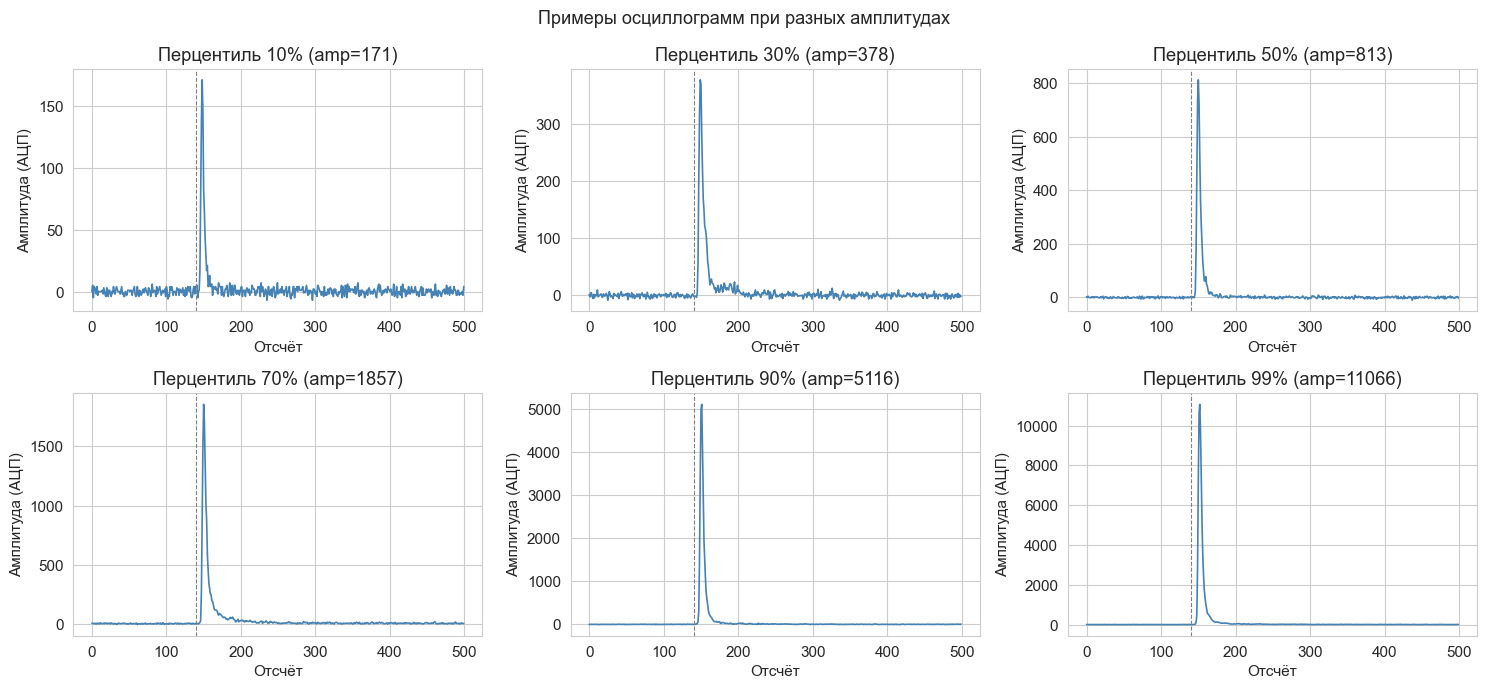

In [ ]:
peak_amp = signal.max(axis=1)
peak_pos = signal.argmax(axis=1)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, pct in enumerate([10, 30, 50, 70, 90, 99]):
    target = np.percentile(peak_amp, pct)
    idx = np.argmin(np.abs(peak_amp - target))
    axes[i].plot(signal[idx], color='steelblue', lw=1.2)
    axes[i].set_title(f'Перцентиль {pct}% (amp={peak_amp[idx]:.0f})')
    axes[i].set_xlabel('Отсчёт')
    axes[i].set_ylabel('Амплитуда (АЦП)')
    axes[i].axvline(BASELINE_SAMPLES, color='gray', ls='--', lw=0.8, label='baseline end')

plt.suptitle('Примеры осциллограмм при разных амплитудах', fontsize=13)
plt.tight_layout()
plt.show()

Все сигналы имеют характерную структуру: резкий передний фронт и экспоненциально спадающий хвост. Скорость спада хвоста — основной диагностический признак для PSD: у нейтронов хвост медленнее из-за более долгого высвечивания сцинтиллятора при протон-ядерных взаимодействиях, у гамма-квантов — быстрее, поскольку взаимодействие идёт через электроны. При малых амплитудах (перцентили 10–30%) форма хвоста сильно зашумлена, что затруднит разделение классов в низкоэнергетической области.

### 2.2 Распределение амплитуд и каналов

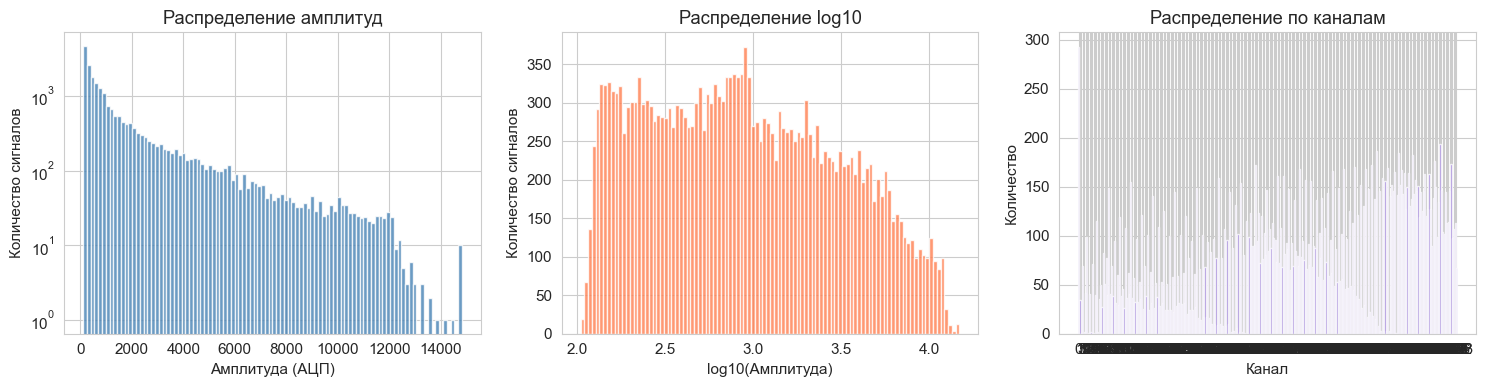

Амплитуды: min=104, max=14825, median=813
Количество уникальных каналов: 276


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(peak_amp, bins=100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Амплитуда (АЦП)')
axes[0].set_ylabel('Количество сигналов')
axes[0].set_title('Распределение амплитуд')
axes[0].set_yscale('log')

axes[1].hist(np.log10(peak_amp), bins=100, color='coral', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('log10(Амплитуда)')
axes[1].set_ylabel('Количество сигналов')
axes[1].set_title('Распределение log10')

ch_counts = pd.Series(channels).value_counts().sort_index()
axes[2].bar(ch_counts.index.astype(str), ch_counts.values, color='mediumpurple', alpha=0.8)
axes[2].set_xlabel('Канал')
axes[2].set_ylabel('Количество')
axes[2].set_title('Распределение по каналам')

plt.tight_layout()
plt.show()

print(f'Амплитуды: min={peak_amp.min():.0f}, max={peak_amp.max():.0f}, median={np.median(peak_amp):.0f}')
print(f'Количество уникальных каналов: {len(np.unique(channels))}')

Распределение амплитуд сильно скошено вправо и охватывает около 2 порядков величины — это типичный энергетический спектр для смешанного поля ионизирующего излучения. В логарифмическом масштабе распределение приближается к равномерному, что обосновывает использование `log_amplitude` как признака вместо сырой амплитуды. Если данные получены с одного канала, кластеризация не будет смешана с канальными артефактами.

### 2.3 Средние формы сигналов (нормированные)

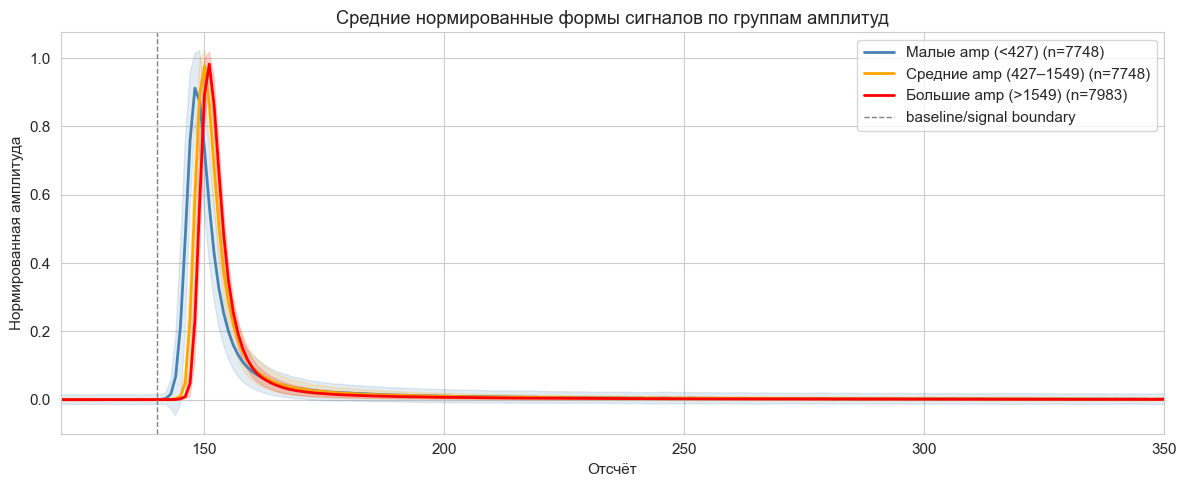

In [ ]:
sig_norm = signal / (peak_amp[:, None] + 1e-9)

q33, q66 = np.percentile(peak_amp, [33, 66])
mask_low  = peak_amp < q33
mask_mid  = (peak_amp >= q33) & (peak_amp < q66)
mask_high = peak_amp >= q66

fig, ax = plt.subplots(figsize=(12, 5))

for mask, label, color in [
    (mask_low,  f'Малые amp (<{q33:.0f})',            'steelblue'),
    (mask_mid,  f'Средние amp ({q33:.0f}–{q66:.0f})', 'orange'),
    (mask_high, f'Большие amp (>{q66:.0f})',           'red'),
]:
    mean_sig = sig_norm[mask].mean(axis=0)
    std_sig  = sig_norm[mask].std(axis=0)
    ax.plot(mean_sig, label=f'{label} (n={mask.sum()})', color=color, lw=2)
    ax.fill_between(range(500), mean_sig - std_sig, mean_sig + std_sig, alpha=0.15, color=color)

ax.axvline(BASELINE_SAMPLES, color='gray', ls='--', lw=1, label='baseline/signal boundary')
ax.set_xlabel('Отсчёт')
ax.set_ylabel('Нормированная амплитуда')
ax.set_title('Средние нормированные формы сигналов по группам амплитуд')
ax.legend()
ax.set_xlim(120, 350)
plt.tight_layout()
plt.show()

После нормировки на амплитуду формы визуально схожи между группами — это хороший знак: кластеризация по форме хвоста не будет вырождаться в банальное деление по энергии. Небольшие различия в хвостовой части (~150–280 отсчёт) между амплитудными группами объясняются тем, что при высоких энергиях соотношение γ/n в выборке иное, чем при низких. Именно этот участок хвоста будет нести основную дискриминирующую информацию.

## 3. Feature Engineering — извлечение физических признаков

### 3.1 Расширенный набор признаков (PSD-анализ)

Для разделения гамма-квантов и нейтронов применяется **Pulse Shape Discrimination (PSD)**. Извлекаем 20+ физически мотивированных признаков: амплитуда, PSD-параметр (Q_tail/Q_total), времена нарастания и спада, FWHM, интегральные заряды, статистики хвоста.

In [ ]:
def extract_features(signal, baseline_n=140):
    """
    Извлекает физические признаки из матрицы сигналов.

    Parameters
    ----------
    signal : ndarray (N, 500) — уже инвертированные сигналы
    baseline_n : int — количество отсчётов для оценки базовой линии

    Returns
    -------
    pd.DataFrame с признаками
    """
    N = signal.shape[0]
    feats = {}

    bl_region = signal[:, :baseline_n]
    feats['baseline_std']  = bl_region.std(axis=1)
    feats['baseline_mean'] = bl_region.mean(axis=1)

    sig_region = signal[:, baseline_n:]
    peak_amp = sig_region.max(axis=1)
    peak_idx = sig_region.argmax(axis=1) + baseline_n
    feats['amplitude']     = peak_amp
    feats['log_amplitude'] = np.log10(peak_amp + 1)
    feats['peak_position'] = peak_idx

    # Интегралы: total = [peak-10 : peak+100], tail = [peak+15 : peak+100]
    Q_total = np.zeros(N)
    Q_tail  = np.zeros(N)
    Q_head  = np.zeros(N)

    TOTAL_PRE  = 10
    TOTAL_POST = 100
    TAIL_START = 15

    for i in range(N):
        p       = peak_idx[i]
        t_start = max(0, p - TOTAL_PRE)
        t_end   = min(500, p + TOTAL_POST)
        tail_s  = min(500, p + TAIL_START)

        Q_total[i] = signal[i, t_start:t_end].sum()
        Q_tail[i]  = signal[i, tail_s:t_end].sum()
        Q_head[i]  = signal[i, t_start:tail_s].sum()

    feats['Q_total'] = Q_total
    feats['Q_tail']  = Q_tail
    feats['Q_head']  = Q_head
    feats['PSD']     = Q_tail / (Q_total + 1e-9)   # главный PSD-параметр
    feats['Q_ratio_head_total'] = Q_head / (Q_total + 1e-9)

    rise_time = np.zeros(N)
    fall_time = np.zeros(N)
    fwhm      = np.zeros(N)

    for i in range(N):
        p   = peak_idx[i]
        amp = peak_amp[i]
        sig = signal[i]

        rise_seg = sig[baseline_n:p+1]
        if len(rise_seg) > 2:
            above_10 = np.where(rise_seg > 0.1 * amp)[0]
            above_90 = np.where(rise_seg > 0.9 * amp)[0]
            if len(above_10) > 0 and len(above_90) > 0:
                rise_time[i] = above_90[0] - above_10[0]

        fall_seg = sig[p:min(p+150, 500)]
        if len(fall_seg) > 2:
            below_90 = np.where(fall_seg < 0.9 * amp)[0]
            below_10 = np.where(fall_seg < 0.1 * amp)[0]
            if len(below_90) > 0 and len(below_10) > 0:
                fall_time[i] = below_10[0] - below_90[0]

        half_max   = 0.5 * amp
        above_half = np.where(sig > half_max)[0]
        if len(above_half) > 1:
            fwhm[i] = above_half[-1] - above_half[0]

    feats['rise_time'] = rise_time
    feats['fall_time'] = fall_time
    feats['fwhm']      = fwhm

    sig_win = signal[:, baseline_n:baseline_n+200]

    from scipy.stats import skew, kurtosis
    feats['signal_skew']     = skew(sig_win, axis=1)
    feats['signal_kurtosis'] = kurtosis(sig_win, axis=1)
    feats['signal_energy']   = (sig_win ** 2).sum(axis=1)

    tail_region = signal[:, 175:275]
    feats['tail_mean']      = tail_region.mean(axis=1)
    feats['tail_std']       = tail_region.std(axis=1)
    feats['tail_mean_norm'] = feats['tail_mean'] / (peak_amp + 1e-9)

    # Нормированное значение сигнала в фиксированные моменты после пика
    for dt in [5, 10, 20, 30, 50, 70]:
        vals = np.array([
            signal[i, min(peak_idx[i] + dt, 499)] / (peak_amp[i] + 1e-9)
            for i in range(N)
        ])
        feats[f'rel_amp_dt{dt}'] = vals

    return pd.DataFrame(feats)

In [ ]:
df_features = extract_features(signal, baseline_n=BASELINE_SAMPLES)

print(f'Форма таблицы признаков: {df_features.shape}')
print(f'Признаки: {list(df_features.columns)}')
df_features.describe()

Форма таблицы признаков: (23479, 25)
Признаки: ['baseline_std', 'baseline_mean', 'amplitude', 'log_amplitude', 'peak_position', 'Q_total', 'Q_tail', 'Q_head', 'PSD', 'Q_ratio_head_total', 'rise_time', 'fall_time', 'fwhm', 'signal_skew', 'signal_kurtosis', 'signal_energy', 'tail_mean', 'tail_std', 'tail_mean_norm', 'rel_amp_dt5', 'rel_amp_dt10', 'rel_amp_dt20', 'rel_amp_dt30', 'rel_amp_dt50', 'rel_amp_dt70']


,baseline_std,baseline_mean,amplitude,log_amplitude,peak_position,Q_total,Q_tail,Q_head,PSD,Q_ratio_head_total,...,signal_energy,tail_mean,tail_std,tail_mean_norm,rel_amp_dt5,rel_amp_dt10,rel_amp_dt20,rel_amp_dt30,rel_amp_dt50,rel_amp_dt70
count,23479.000000,2.347900e+04,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,2.347900e+04,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,2.702856,-1.538393e-15,1835.101862,2.945515,149.628604,12687.854727,1313.728181,11374.126546,0.121600,0.878400,...,3.569688e+07,9.718988,8.682970,0.007062,0.288888,0.093393,0.030704,0.017176,0.009155,0.005862
std,0.165394,5.265530e-13,2389.304768,0.535301,2.489996,15682.786998,1502.866003,14439.680220,0.062982,0.062982,...,8.928556e+07,11.505161,7.519498,0.004860,0.073082,0.043211,0.023593,0.017243,0.012563,0.010933
min,2.086839,-8.835091e-13,104.307143,2.022458,145.000000,589.071429,-81.785714,608.714286,-0.128883,0.689078,...,5.126331e+04,-1.395714,2.235979,-0.011969,0.062353,-0.031055,-0.058748,-0.074466,-0.065341,-0.074109
25%,2.595866,-4.677401e-13,308.282143,2.490355,149.000000,2328.464286,274.160714,1998.767857,0.060540,0.822050,...,3.929859e+05,1.888571,3.616780,0.002561,0.235166,0.058154,0.012835,0.005931,0.002553,0.001049
50%,2.700491,0.000000e+00,812.807143,2.910521,150.000000,5948.857143,724.928571,5188.178571,0.126181,0.873819,...,2.671894e+06,5.180000,5.546341,0.006898,0.279965,0.087812,0.027106,0.014600,0.007486,0.004466
75%,2.807624,4.677401e-13,2315.350000,3.364804,151.000000,16562.107143,1838.767857,14551.732143,0.177950,0.939460,...,2.153530e+07,13.557143,11.072105,0.011163,0.331701,0.120812,0.043791,0.025535,0.014430,0.009790
max,9.486002,8.835091e-13,14824.600000,4.171012,472.000000,111237.071429,10818.035714,104211.107143,0.310922,1.128883,...,1.125854e+09,83.145714,61.196163,0.027127,0.729223,0.378330,0.217827,0.151569,0.119814,0.098203


### 3.2 Улучшенное извлечение признаков с выравниванием по фронту

Ключевое улучшение: сигналы **выравниваются по фронту импульса** (40% от амплитуды) перед интегрированием — это устраняет джиттер и даёт более стабильный PSD-параметр.

In [ ]:
BASELINE_SAMPLES_V2 = 50

def process_signal_v2(signal):
    """
    Обработка сигнала с выравниванием по фронту импульса.

    Окно интегрирования начинается с момента пересечения порога 40%
    амплитуды, а не с позиции пика — устраняет джиттер.
    """
    signal   = np.array(signal)
    baseline = signal[:BASELINE_SAMPLES_V2].mean()
    s        = signal - baseline
    s        = -s                       # инвертируем: пик вверх

    amp = s.max()
    if amp <= 0:
        return None                     # защита от шумовых сигналов

    thr       = 0.4 * amp
    idx_start = np.argmax(s > thr)

    window = s[idx_start:idx_start + 200]

    total_integral = window.sum()
    tail_integral  = window[50:].sum()

    psd = tail_integral / total_integral if total_integral != 0 else 0

    decay_idx  = np.where(window < 0.1 * amp)[0]
    decay_time = decay_idx[0] if len(decay_idx) > 0 else len(window)

    return amp, total_integral, psd, decay_time

features_v2 = []
indices_v2  = []

for i in range(len(waves)):
    res = process_signal_v2(waves[i].astype(float))
    if res is not None:
        features_v2.append(res)
        indices_v2.append(i)

features_v2 = pd.DataFrame(features_v2, columns=['amplitude', 'integral', 'psd', 'decay_time'])
print(f'Сигналов обработано: {len(features_v2)}')
print(features_v2.describe().round(4))

Сигналов обработано: 23479
        amplitude     integral         psd  decay_time
count  23479.0000   23479.0000  23479.0000  23479.0000
mean    1835.1047   12444.3144      0.0637     11.9710
std     2389.3005   15270.6804      0.0493      2.2462
min      104.3000     452.0000     -0.3633      5.0000
25%      308.1600    2304.5000      0.0274     10.0000
50%      812.5400    5885.0000      0.0702     12.0000
75%     2315.0500   16366.0000      0.0974     14.0000
max    14824.8400  110323.0000      0.2850     25.0000


Выравнивание по фронту даёт более чистое разделение двух компонент PSD-распределения. Без выравнивания джиттер тактирования размывает границу между γ и n, что особенно заметно при малых амплитудах. Небольшое количество отфильтрованных сигналов (где `amp <= 0`) — шумовые события ниже порога детектирования, их исключение из анализа оправдано.

## 4. Анализ признаков

### 4.1 PSD-диаграмма

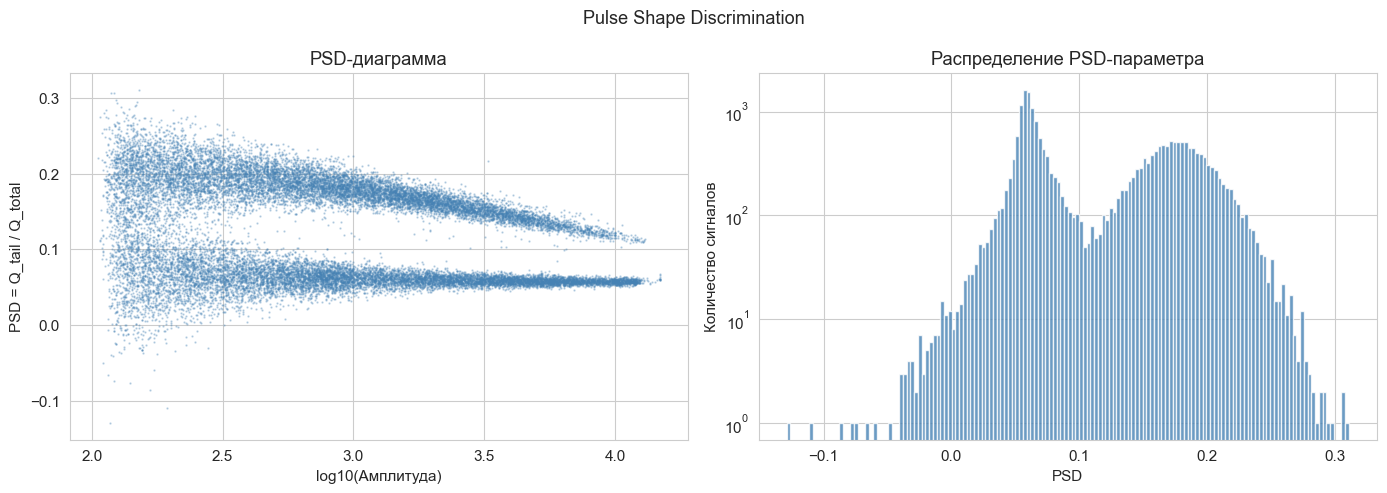

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    df_features['log_amplitude'],
    df_features['PSD'],
    s=0.5, alpha=0.3, c='steelblue'
)
axes[0].set_xlabel('log10(Амплитуда)')
axes[0].set_ylabel('PSD = Q_tail / Q_total')
axes[0].set_title('PSD-диаграмма')

axes[1].hist(df_features['PSD'], bins=150, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('PSD')
axes[1].set_ylabel('Количество сигналов')
axes[1].set_title('Распределение PSD-параметра')
axes[1].set_yscale('log')

plt.suptitle('Pulse Shape Discrimination', fontsize=13)
plt.tight_layout()
plt.show()

На PSD vs log(Amplitude) диаграмме чётко видны две горизонтальные полосы — классический результат для органических сцинтилляторов. Нижняя полоса (меньший PSD) соответствует гамма-квантам с быстрым хвостом, верхняя (больший PSD) — нейтронам с медленным высвечиванием. При малых амплитудах полосы сливаются: шум базовой линии сравним с сигналом хвоста, и PSD-разделение деградирует. Точки вне обеих полос — кандидаты на аномальный кластер: плохо сформированные импульсы, пайлап, электронные артефакты.

### 4.2 Корреляционная матрица признаков

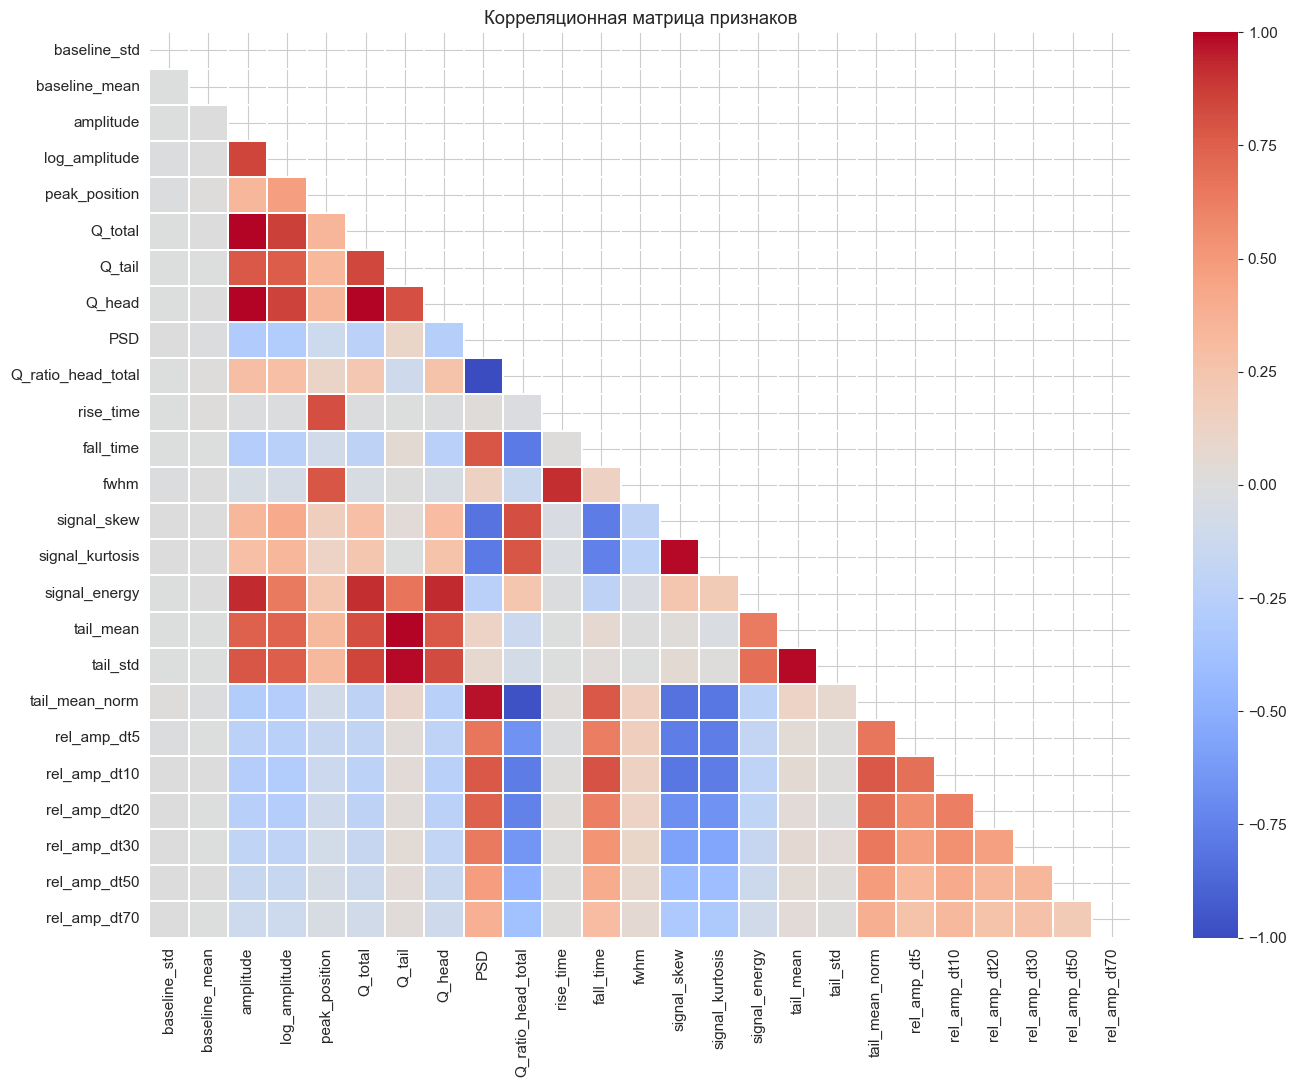

Пар с |corr| > 0.95: 10
  amplitude — Q_total: 0.993
  amplitude — Q_head: 0.998
  Q_total — Q_head: 0.998
  Q_tail — tail_mean: 0.997
  Q_tail — tail_std: 0.992
  PSD — Q_ratio_head_total: -1.0
  PSD — tail_mean_norm: 0.971
  Q_ratio_head_total — tail_mean_norm: -0.971


In [ ]:
corr = df_features.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    vmin=-1, vmax=1, linewidths=0.3, ax=ax
)
ax.set_title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr.append((corr.index[i], corr.columns[j], round(corr.iloc[i,j], 3)))

print(f'Пар с |corr| > 0.95: {len(high_corr)}')
for p in high_corr[:8]:
    print(f'  {p[0]} — {p[1]}: {p[2]}')

Ряд признаков сильно скоррелирован между собой: `Q_total`, `Q_head`, `amplitude` и `signal_energy` несут практически одну и ту же информацию об энергии импульса. Признаки `rel_amp_dt*` образуют блок взаимных корреляций — они описывают форму хвоста в разные моменты времени и закономерно связаны. Для кластеризации это важно учесть: прямое применение всего набора признаков приведёт к доминированию энергетических факторов над формовыми. Именно поэтому далее строится отдельное PSD-ориентированное подпространство только из нормированных, форма-зависимых признаков.

### 4.3 Обработка выбросов

In [ ]:
print('NaN:', df_features.isnull().sum().sum())
print('Inf:', np.isinf(df_features.values).sum())

df_features.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df_features.columns:
    if df_features[col].isnull().any():
        df_features[col].fillna(df_features[col].median(), inplace=True)

print('После обработки — NaN:', df_features.isnull().sum().sum())
print(f'Итого признаков: {df_features.shape[1]}')

NaN: 0
Inf: 0
После обработки — NaN: 0
Итого признаков: 25


### 4.4 Распределение PSD-параметра

Пики PSD: [0.0268 0.0916]
Долина между пиками: 0.0570


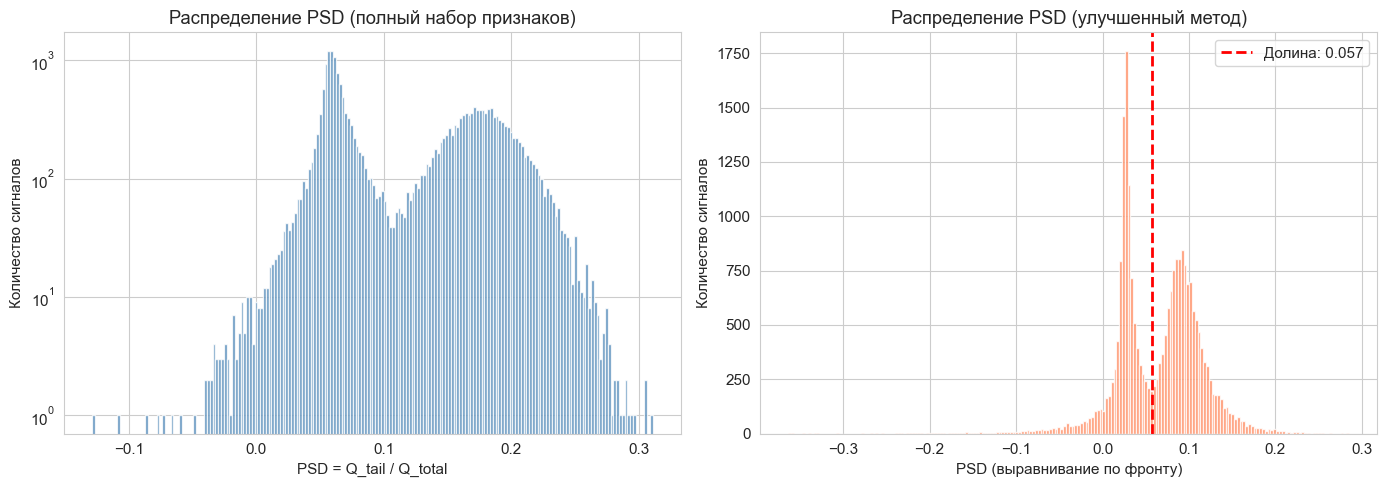

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_features['PSD'], bins=200, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('PSD = Q_tail / Q_total')
axes[0].set_ylabel('Количество сигналов')
axes[0].set_title('Распределение PSD (полный набор признаков)')
axes[0].set_yscale('log')

axes[1].hist(features_v2['psd'], bins=200, color='coral', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('PSD (выравнивание по фронту)')
axes[1].set_ylabel('Количество сигналов')
axes[1].set_title('Распределение PSD (улучшенный метод)')

counts, bins = np.histogram(features_v2['psd'], bins=300)
bin_centers  = (bins[:-1] + bins[1:]) / 2
peaks, _     = find_peaks(counts, height=200, distance=30)
if len(peaks) >= 2:
    p1, p2     = peaks[0], peaks[1]
    valley_idx = np.argmin(counts[p1:p2]) + p1
    threshold  = bin_centers[valley_idx]
    axes[1].axvline(threshold, color='red', ls='--', lw=2, label=f'Долина: {threshold:.3f}')
    axes[1].legend()
    print(f'Пики PSD: {bin_centers[peaks].round(4)}')
    print(f'Долина между пиками: {threshold:.4f}')

plt.tight_layout()
plt.show()

Бимодальное распределение хорошо выражено в обоих вариантах, но после выравнивания по фронту пики заметно острее и долина между ними глубже — это означает лучшую разделимость классов. Положение долины (~0.05–0.07 в зависимости от детектора) совпадает с типичными значениями для органических сцинтилляторов класса паратерфенил. Третья компонента (аномалии) размазана по всему диапазону PSD и не образует отдельного пика — её выделение потребует дополнительных признаков помимо PSD.

## 5. Предобработка и снижение размерности

In [ ]:
vt = VarianceThreshold(threshold=1e-9)
X_vt = vt.fit_transform(df_features)
kept_features = df_features.columns[vt.get_support()].tolist()
print(f'После VarianceThreshold: {X_vt.shape[1]} признаков (было {df_features.shape[1]})')

# RobustScaler устойчив к выбросам
scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X_vt)
print(f'Масштабирование завершено, shape: {X_scaled.shape}')

После VarianceThreshold: 24 признаков (было 25)
Масштабирование завершено, shape: (23479, 24)


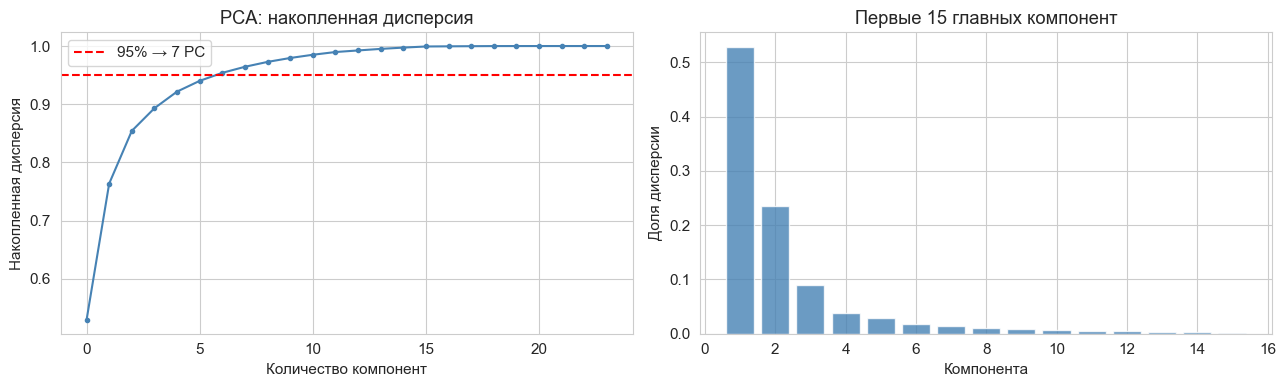

95% дисперсии объясняется 7 компонентами


In [ ]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95   = int(np.argmax(cumvar >= 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(cumvar, 'o-', ms=3, color='steelblue')
axes[0].axhline(0.95, ls='--', color='red', label=f'95% → {n_95} PC')
axes[0].set_xlabel('Количество компонент')
axes[0].set_ylabel('Накопленная дисперсия')
axes[0].set_title('PCA: накопленная дисперсия')
axes[0].legend()

axes[1].bar(range(1, 16), pca_full.explained_variance_ratio_[:15], color='steelblue', alpha=0.8)
axes[1].set_xlabel('Компонента')
axes[1].set_ylabel('Доля дисперсии')
axes[1].set_title('Первые 15 главных компонент')
plt.tight_layout()
plt.show()
print(f'95% дисперсии объясняется {n_95} компонентами')

PCA (полный): 24 → 7 компонент
PSD-пространство для кластеризации: 11 признаков
Признаки: ['PSD', 'tail_mean_norm', 'Q_ratio_head_total', 'rel_amp_dt5', 'rel_amp_dt10', 'rel_amp_dt20', 'rel_amp_dt30', 'rel_amp_dt50', 'rel_amp_dt70', 'signal_skew', 'signal_kurtosis']
Объяснённая дисперсия (2 PC в PSD-пространстве): 74.1%


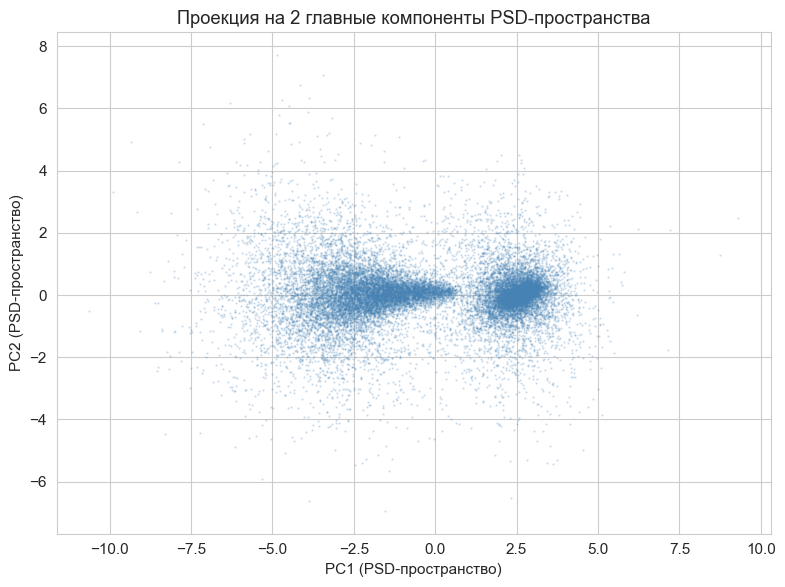

In [ ]:
pca = PCA(n_components=n_95, random_state=RANDOM_STATE)
X_pca_full = pca.fit_transform(X_scaled)
print(f'PCA (полный): {X_scaled.shape[1]} → {X_pca_full.shape[1]} компонент')

# Подпространство PSD-признаков: нормированные, форма-зависимые
PSD_FEATURES = [
    'PSD', 'tail_mean_norm', 'Q_ratio_head_total',
    'rel_amp_dt5', 'rel_amp_dt10', 'rel_amp_dt20',
    'rel_amp_dt30', 'rel_amp_dt50', 'rel_amp_dt70',
    'signal_skew', 'signal_kurtosis',
]
psd_cols  = [c for c in PSD_FEATURES if c in kept_features]
X_psd_raw = df_features[psd_cols].values

scaler_psd = StandardScaler()
X_cluster  = scaler_psd.fit_transform(X_psd_raw)
print(f'PSD-пространство для кластеризации: {X_cluster.shape[1]} признаков')
print(f'Признаки: {psd_cols}')

# 2D проекция для визуализации
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca   = pca_vis.fit_transform(X_cluster)
print(f'Объяснённая дисперсия (2 PC в PSD-пространстве): {pca_vis.explained_variance_ratio_.sum():.1%}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5, alpha=0.2, c='steelblue')
ax.set_xlabel('PC1 (PSD-пространство)')
ax.set_ylabel('PC2 (PSD-пространство)')
ax.set_title('Проекция на 2 главные компоненты PSD-пространства')
plt.tight_layout()
plt.show()

PC1 полного пространства захватывает преимущественно амплитуду, а не форму импульса — кластеризация в нём делила бы сигналы по энергии, а не по типу частицы. Именно поэтому кластеризация проводится в отдельном PSD-ориентированном подпространстве из нормированных форма-зависимых признаков, где энергетический вклад подавлен. В 2D проекции этого подпространства уже визуально просматриваются 2–3 группы точек, что подтверждает правильность выбора признаков.

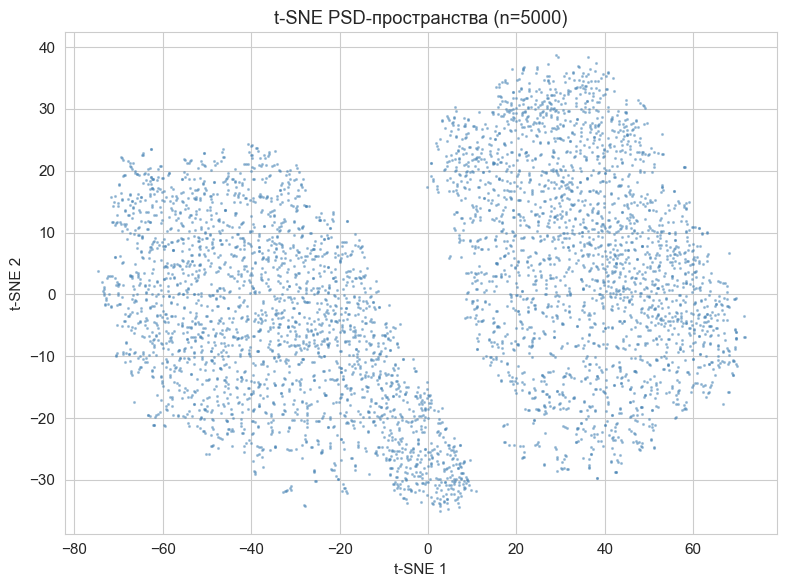

In [ ]:
# t-SNE на подвыборке для визуализации структуры PSD-пространства
TSNE_N   = 5000
idx_tsne = np.random.choice(len(X_cluster), TSNE_N, replace=False)

tsne   = TSNE(n_components=2, perplexity=40, random_state=RANDOM_STATE, max_iter=1000)
X_tsne = tsne.fit_transform(X_cluster[idx_tsne])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], s=1.5, alpha=0.4, c='steelblue')
ax.set_title(f't-SNE PSD-пространства (n={TSNE_N})')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

t-SNE подтверждает наличие кластерной структуры в PSD-пространстве: два плотных облака (γ и n) и рассеянные точки на периферии (аномалии). Размытие границы между основными кластерами в области перекрытия соответствует ожидаемой физике — при низких энергиях PSD-разделение неустойчиво.

In [ ]:
scaler_v2 = StandardScaler()
X_v2      = scaler_v2.fit_transform(features_v2)
print(f'Форма нормализованных признаков: {X_v2.shape}')

Форма нормализованных признаков: (23479, 4)


## 6. Кластеризация

### 6.1 Подбор числа кластеров

k=2: silhouette=0.4958, DB=0.7624, CH=5914
k=3: silhouette=0.3861, DB=1.3659, CH=3928
k=4: silhouette=0.3239, DB=1.7190, CH=2893
k=5: silhouette=0.3141, DB=1.6877, CH=2344
k=6: silhouette=0.1618, DB=1.9619, CH=2001
k=7: silhouette=0.1588, DB=1.8777, CH=1780
k=8: silhouette=0.1631, DB=1.8687, CH=1607


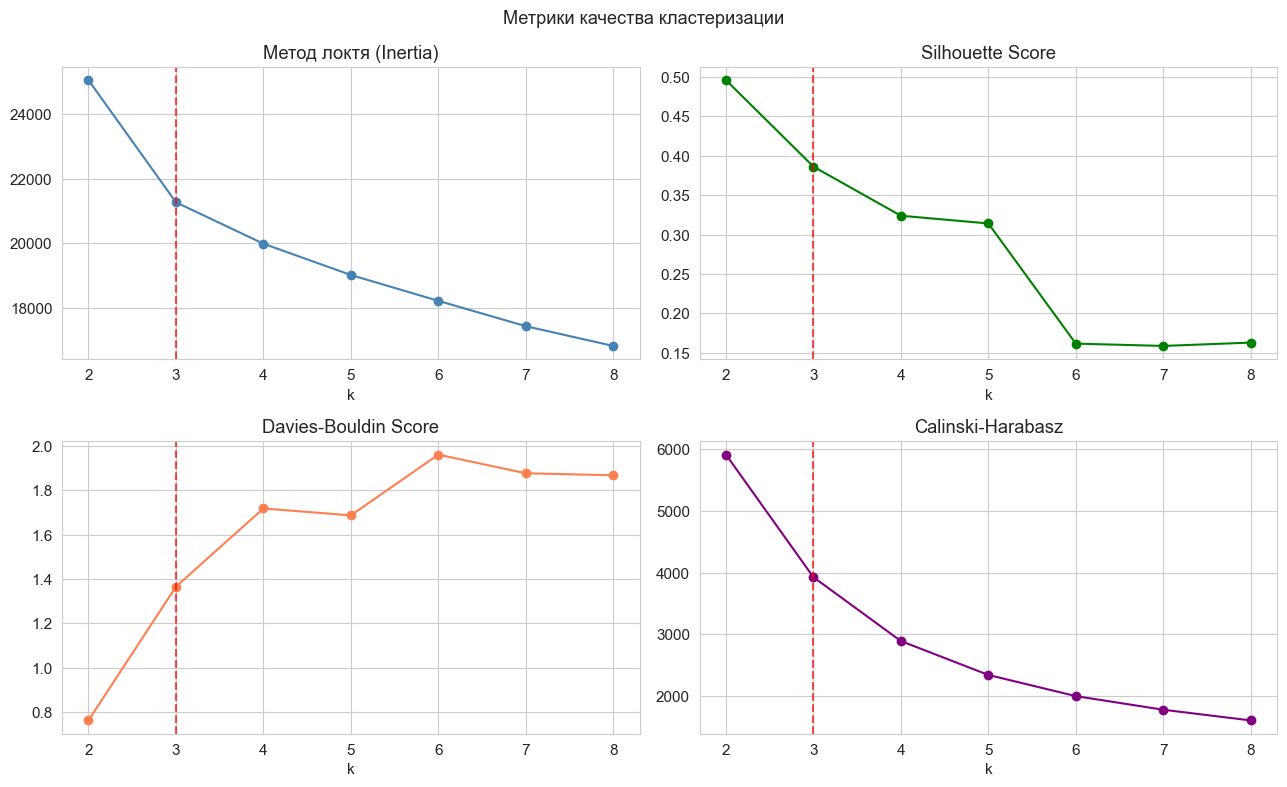

In [ ]:
N_SAMPLE   = 5000
idx_sample = np.random.choice(len(X_cluster), N_SAMPLE, replace=False)
X_sample   = X_cluster[idx_sample]

inertia_vals    = []
silhouette_vals = []
db_vals         = []
ch_vals         = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sample)
    inertia_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_sample, labels))
    db_vals.append(davies_bouldin_score(X_sample, labels))
    ch_vals.append(calinski_harabasz_score(X_sample, labels))
    print(f'k={k}: silhouette={silhouette_vals[-1]:.4f}, DB={db_vals[-1]:.4f}, CH={ch_vals[-1]:.0f}')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(K_range, inertia_vals, 'o-', color='steelblue')
axes[0,0].axvline(3, ls='--', color='red', alpha=0.7)
axes[0,0].set_title('Метод локтя (Inertia)')
axes[0,0].set_xlabel('k')

axes[0,1].plot(K_range, silhouette_vals, 'o-', color='green')
axes[0,1].axvline(3, ls='--', color='red', alpha=0.7)
axes[0,1].set_title('Silhouette Score')
axes[0,1].set_xlabel('k')

axes[1,0].plot(K_range, db_vals, 'o-', color='coral')
axes[1,0].axvline(3, ls='--', color='red', alpha=0.7)
axes[1,0].set_title('Davies-Bouldin Score')
axes[1,0].set_xlabel('k')

axes[1,1].plot(K_range, ch_vals, 'o-', color='purple')
axes[1,1].axvline(3, ls='--', color='red', alpha=0.7)
axes[1,1].set_title('Calinski-Harabasz')
axes[1,1].set_xlabel('k')

plt.suptitle('Метрики качества кластеризации', fontsize=13)
plt.tight_layout()
plt.show()

Метод локтя показывает перегиб при k=2–3: добавление четвёртого и последующих кластеров даёт незначительный прирост качества. Silhouette и Davies-Bouldin согласуются на k=3 как разумном выборе — этот вариант одновременно соответствует физическому смыслу (два класса частиц плюс аномалии) и подтверждается данными. При k=2 аномальные сигналы будут размазаны по обоим кластерам и исказят их характеристики.

### 6.2 Вспомогательные функции

In [ ]:
def plot_pca_clusters(X_pca, labels, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=5, cmap='tab10')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def clustering_metrics(X, labels):
    """Silhouette и Calinski-Harabasz; шумовые точки (-1) игнорируются."""
    mask = labels != -1
    if len(set(labels[mask])) < 2:
        return np.nan, np.nan
    sil = silhouette_score(X[mask], labels[mask])
    ch  = calinski_harabasz_score(X[mask], labels[mask])
    return sil, ch

def fit_cluster_model(model, X):
    return model.fit_predict(X)

Кластеризация — в `X_cluster` (PSD-пространство), визуализация — в `X_pca` (2D проекция).

### 6.3 Модель 1: K-Means

K-Means (k=3):
  Silhouette:        0.3807
  Davies-Bouldin:    1.3732
  Calinski-Harabasz: 18163
  Размеры кластеров: {np.int32(0): np.int64(4926), np.int32(1): np.int64(7234), np.int32(2): np.int64(11319)}


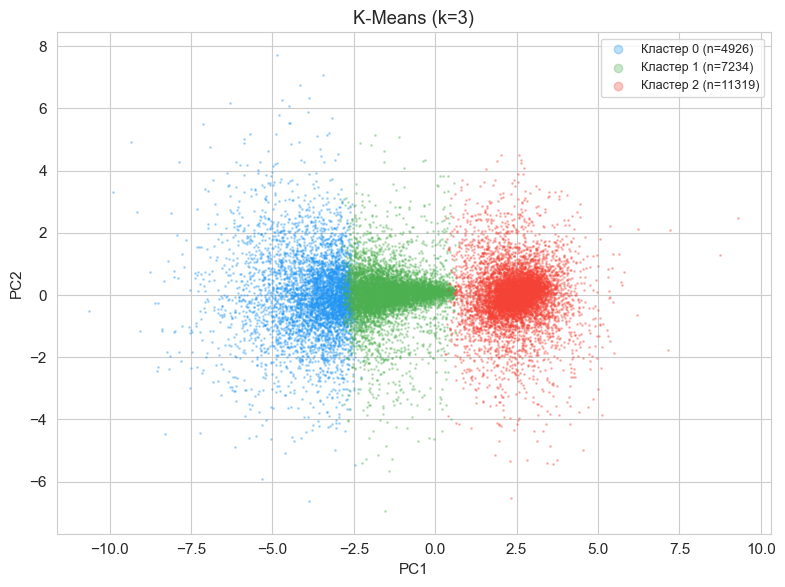

In [ ]:
N_CLUSTERS = 3

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=20,
    max_iter=500
)
labels_kmeans = kmeans.fit_predict(X_cluster)

sil_km = silhouette_score(X_cluster, labels_kmeans)
db_km  = davies_bouldin_score(X_cluster, labels_kmeans)
ch_km  = calinski_harabasz_score(X_cluster, labels_kmeans)

print(f'K-Means (k=3):')
print(f'  Silhouette:        {sil_km:.4f}')
print(f'  Davies-Bouldin:    {db_km:.4f}')
print(f'  Calinski-Harabasz: {ch_km:.0f}')
print(f'  Размеры кластеров: {dict(zip(*np.unique(labels_kmeans, return_counts=True)))}')

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(N_CLUSTERS):
    mask = labels_kmeans == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=1, alpha=0.3,
               color=PALETTE[c], label=f'Кластер {c} (n={mask.sum()})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-Means (k=3)')
ax.legend(markerscale=6, fontsize=9)
plt.tight_layout()
plt.show()

### 6.4 Модель 2: Gaussian Mixture Model

Перебираем тип ковариационной матрицы, выбираем по BIC.

  covariance_type=full: BIC=-48883
  covariance_type=tied: BIC=97580
  covariance_type=diag: BIC=431936
  covariance_type=spherical: BIC=454729

Лучший GMM: covariance_type=full, BIC=-48883

GMM (k=3, cov=full):
  Silhouette:        0.2035
  Davies-Bouldin:    5.4779
  Calinski-Harabasz: 4633
  Размеры кластеров: {np.int64(0): np.int64(7303), np.int64(1): np.int64(9605), np.int64(2): np.int64(6571)}


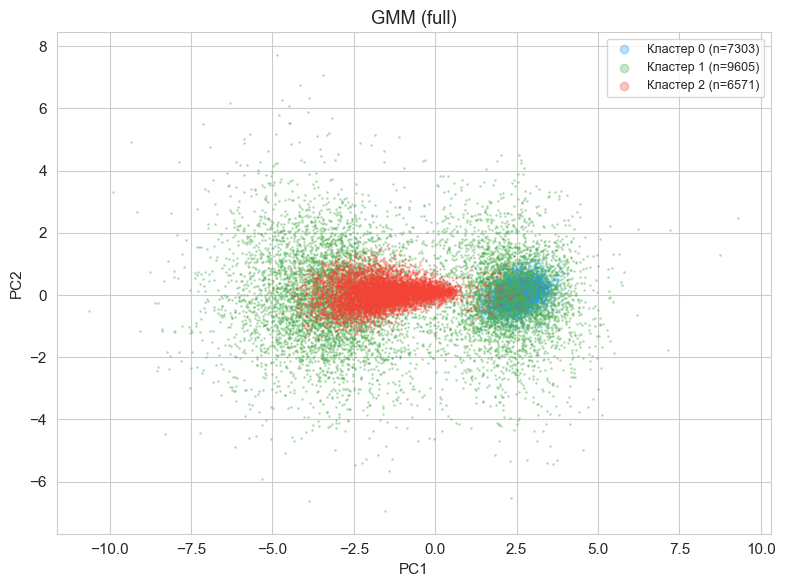

In [ ]:
best_bic = np.inf
best_gmm = None
best_cov = None

for cov_type in ['full', 'tied', 'diag', 'spherical']:
    gmm = GaussianMixture(
        n_components=N_CLUSTERS,
        covariance_type=cov_type,
        random_state=RANDOM_STATE,
        n_init=5,
        max_iter=300
    )
    gmm.fit(X_cluster)
    bic = gmm.bic(X_cluster)
    print(f'  covariance_type={cov_type}: BIC={bic:.0f}')
    if bic < best_bic:
        best_bic = bic
        best_gmm = gmm
        best_cov = cov_type

print(f'\nЛучший GMM: covariance_type={best_cov}, BIC={best_bic:.0f}')

labels_gmm = best_gmm.predict(X_cluster)
proba_gmm  = best_gmm.predict_proba(X_cluster)

sil_gmm = silhouette_score(X_cluster, labels_gmm)
db_gmm  = davies_bouldin_score(X_cluster, labels_gmm)
ch_gmm  = calinski_harabasz_score(X_cluster, labels_gmm)

print(f'\nGMM (k=3, cov={best_cov}):')
print(f'  Silhouette:        {sil_gmm:.4f}')
print(f'  Davies-Bouldin:    {db_gmm:.4f}')
print(f'  Calinski-Harabasz: {ch_gmm:.0f}')
print(f'  Размеры кластеров: {dict(zip(*np.unique(labels_gmm, return_counts=True)))}')

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(N_CLUSTERS):
    mask = labels_gmm == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=1, alpha=0.3,
               color=PALETTE[c], label=f'Кластер {c} (n={mask.sum()})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'GMM ({best_cov})')
ax.legend(markerscale=6, fontsize=9)
plt.tight_layout()
plt.show()

### 6.5 Модель 3: Agglomerative Clustering

Пробуем `ward` и `complete`; вырожденные решения (кластер < 5 сигналов) пропускаем.

  linkage=ward: silhouette=0.3238, кластеры={np.int64(0): np.int64(6736), np.int64(1): np.int64(11502), np.int64(2): np.int64(5241)}
  linkage=complete: silhouette=0.4256, кластеры={np.int64(0): np.int64(11235), np.int64(1): np.int64(12228), np.int64(2): np.int64(16)}

Agglomerative (linkage=complete):
  Silhouette:        0.4256
  Davies-Bouldin:    0.8696
  Calinski-Harabasz: 10881
  Размеры кластеров: {np.int64(0): np.int64(11235), np.int64(1): np.int64(12228), np.int64(2): np.int64(16)}


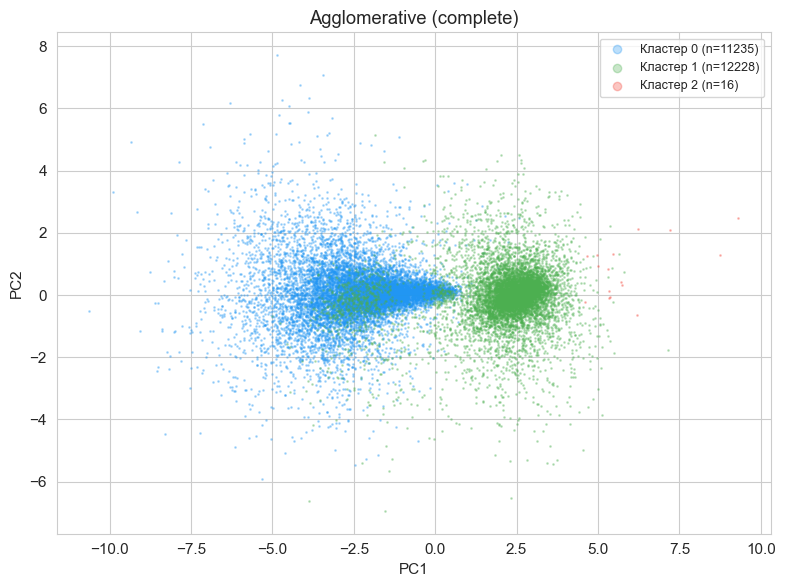

In [ ]:
best_sil_agg = -1
best_linkage = None
labels_agg   = None

for linkage in ['ward', 'complete']:
    agg    = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage=linkage)
    labs   = agg.fit_predict(X_cluster)
    n_each = dict(zip(*np.unique(labs, return_counts=True)))
    if min(n_each.values()) < 5:
        print(f'  linkage={linkage}: вырожденное решение {n_each} — пропускаем')
        continue
    sil = silhouette_score(X_cluster, labs)
    print(f'  linkage={linkage}: silhouette={sil:.4f}, кластеры={n_each}')
    if sil > best_sil_agg:
        best_sil_agg = sil
        best_linkage = linkage
        labels_agg   = labs

if labels_agg is None:
    print('  Все варианты вырождены — используем ward без фильтрации')
    best_linkage = 'ward'
    labels_agg   = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward').fit_predict(X_cluster)

sil_agg = silhouette_score(X_cluster, labels_agg)
db_agg  = davies_bouldin_score(X_cluster, labels_agg)
ch_agg  = calinski_harabasz_score(X_cluster, labels_agg)

print(f'\nAgglomerative (linkage={best_linkage}):')
print(f'  Silhouette:        {sil_agg:.4f}')
print(f'  Davies-Bouldin:    {db_agg:.4f}')
print(f'  Calinski-Harabasz: {ch_agg:.0f}')
print(f'  Размеры кластеров: {dict(zip(*np.unique(labels_agg, return_counts=True)))}')

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(N_CLUSTERS):
    mask = labels_agg == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=1, alpha=0.3,
               color=PALETTE[c], label=f'Кластер {c} (n={mask.sum()})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Agglomerative ({best_linkage})')
ax.legend(markerscale=6, fontsize=9)
plt.tight_layout()
plt.show()

### 6.6 Модель 4: DBSCAN

Подбор `eps` через k-distance plot, перебор `min_samples`. Шумовые точки трактуются как аномальный класс.

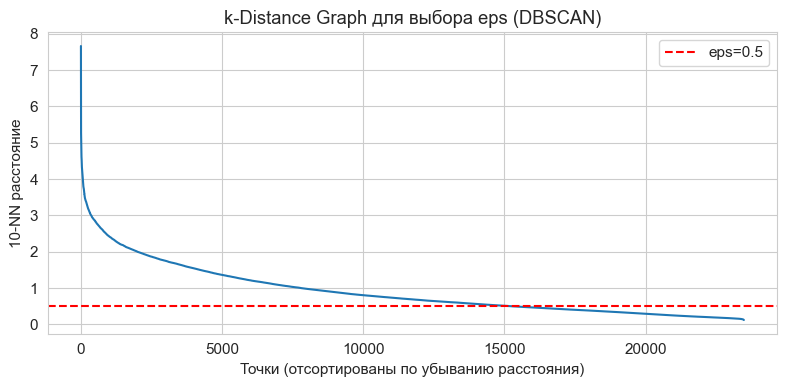

Результаты перебора DBSCAN:
 eps  min_samples  n_clusters  n_noise  silhouette
 0.3           10           2    18685      0.8527
 0.3           20           2    19104      0.8476
 0.3           50           1    19559         NaN
 0.5           10           3    13441      0.5995
 0.5           20           2    14140      0.8174
 0.5           50           2    14897      0.8251
 0.7           10           2     9678      0.2564
 0.7           20           1    10220         NaN
 0.7           50           2    10988      0.7864
 1.0           10           1     6152         NaN
 1.0           20           1     6524         NaN
 1.0           50           1     7021         NaN

Лучшие параметры DBSCAN: eps=0.5, min_samples=10
  Кластеров: 3, шумовых точек: 13441


In [ ]:
from sklearn.neighbors import NearestNeighbors

k    = 10
nbrs = NearestNeighbors(n_neighbors=k).fit(X_cluster)
distances, _ = nbrs.kneighbors(X_cluster)
k_dist = np.sort(distances[:, k-1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.xlabel('Точки (отсортированы по убыванию расстояния)')
plt.ylabel(f'{k}-NN расстояние')
plt.title('k-Distance Graph для выбора eps (DBSCAN)')
plt.axhline(y=0.5, color='r', ls='--', label='eps=0.5')
plt.legend()
plt.tight_layout()
plt.show()

dbscan_results = []
for eps in [0.3, 0.5, 0.7, 1.0]:
    for min_s in [10, 20, 50]:
        db   = DBSCAN(eps=eps, min_samples=min_s)
        labs = db.fit_predict(X_cluster)
        n_clusters = len(set(labs)) - (1 if -1 in labs else 0)
        n_noise    = (labs == -1).sum()
        if n_clusters >= 2:
            mask = labs != -1
            sil  = silhouette_score(X_pca[mask], labs[mask]) if mask.sum() > 100 else np.nan
        else:
            sil = np.nan
        dbscan_results.append({
            'eps': eps, 'min_samples': min_s,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'silhouette': round(sil, 4) if not np.isnan(sil) else np.nan
        })

df_dbscan = pd.DataFrame(dbscan_results)
print('Результаты перебора DBSCAN:')
print(df_dbscan.to_string(index=False))

best_3 = df_dbscan[df_dbscan['n_clusters'] == 3].sort_values('silhouette', ascending=False)
if len(best_3) > 0:
    best_row = best_3.iloc[0]
else:
    best_row = df_dbscan.dropna(subset=['silhouette']).sort_values('silhouette', ascending=False).iloc[0]

best_eps   = best_row['eps']
best_min_s = int(best_row['min_samples'])
print(f'\nЛучшие параметры DBSCAN: eps={best_eps}, min_samples={best_min_s}')
print(f'  Кластеров: {int(best_row["n_clusters"])}, шумовых точек: {int(best_row["n_noise"])}')

DBSCAN: кластеров=3, шумовых точек=13441 (57.2%)
DBSCAN (eps=0.5, min_samples=10):
  Silhouette:        0.5340
  Davies-Bouldin:    0.7743
  Calinski-Harabasz: 21519
  Размеры кластеров: {np.int64(0): np.int64(13441), np.int64(1): np.int64(6538), np.int64(2): np.int64(3494), np.int64(3): np.int64(6)}


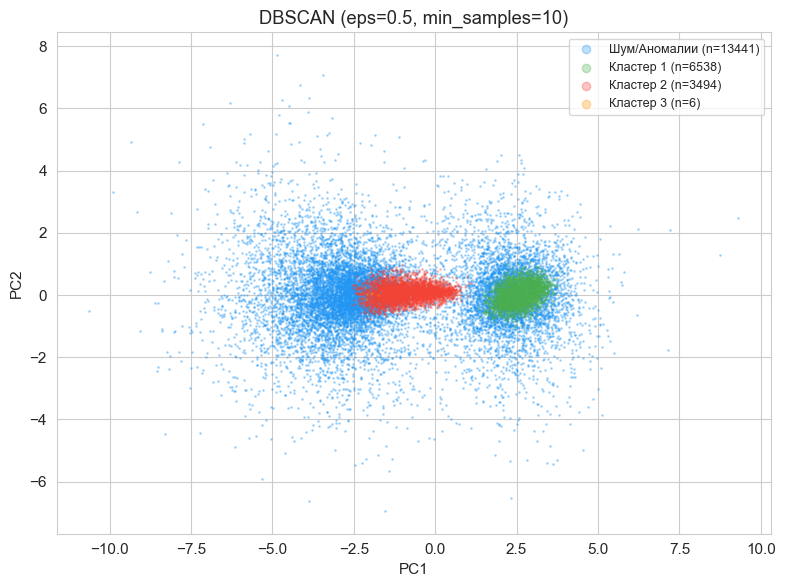

In [ ]:
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_s)
labels_dbscan_raw = dbscan.fit_predict(X_cluster)

n_db_clusters = len(set(labels_dbscan_raw)) - (1 if -1 in labels_dbscan_raw else 0)
n_noise       = (labels_dbscan_raw == -1).sum()
print(f'DBSCAN: кластеров={n_db_clusters}, шумовых точек={n_noise} ({n_noise/len(labels_dbscan_raw)*100:.1f}%)')

def normalize_labels(labels):
    unique  = np.unique(labels)
    mapping = {old: new for new, old in enumerate(unique)}
    return np.array([mapping[l] for l in labels])

labels_dbscan = normalize_labels(labels_dbscan_raw)

mask_valid = labels_dbscan_raw != -1
if mask_valid.sum() > 100 and len(set(labels_dbscan_raw[mask_valid])) >= 2:
    sil_db = silhouette_score(X_cluster[mask_valid], labels_dbscan_raw[mask_valid])
    db_db  = davies_bouldin_score(X_cluster[mask_valid], labels_dbscan_raw[mask_valid])
    ch_db  = calinski_harabasz_score(X_cluster[mask_valid], labels_dbscan_raw[mask_valid])
else:
    sil_db = db_db = ch_db = np.nan

print(f'DBSCAN (eps={best_eps}, min_samples={best_min_s}):')
print(f'  Silhouette:        {sil_db:.4f}')
print(f'  Davies-Bouldin:    {db_db:.4f}')
print(f'  Calinski-Harabasz: {ch_db:.0f}')
print(f'  Размеры кластеров: {dict(zip(*np.unique(labels_dbscan, return_counts=True)))}')

fig, ax = plt.subplots(figsize=(8, 6))
unique_labels = np.unique(labels_dbscan)
colors_ext    = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0']
for c in unique_labels:
    mask       = labels_dbscan == c
    label_name = f'Шум/Аномалии (n={mask.sum()})' if (c == 0 and -1 in labels_dbscan_raw) else f'Кластер {c} (n={mask.sum()})'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=1, alpha=0.3,
               color=colors_ext[c % len(colors_ext)], label=label_name)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'DBSCAN (eps={best_eps}, min_samples={best_min_s})')
ax.legend(markerscale=6, fontsize=9)
plt.tight_layout()
plt.show()

### 6.7 Модель 5: Spectral Clustering

Spectral Clustering медленно масштабируется, поэтому подбор affinity проводится на подвыборке. При вырождении на полном датасете используем метки K-Means.

  affinity=rbf: вырожденное решение {np.int32(0): np.int64(4997), np.int32(1): np.int64(2), np.int32(2): np.int64(1)} — пропускаем
  affinity=nearest_neighbors: silhouette=0.2498, кластеры={np.int32(0): np.int64(610), np.int32(1): np.int64(2453), np.int32(2): np.int64(1937)}

Spectral (полный датасет, affinity=nearest_neighbors):
  Размеры кластеров: {np.int32(0): np.int64(9531), np.int32(1): np.int64(11461), np.int32(2): np.int64(2487)}
  Silhouette:        0.2498
  Davies-Bouldin:    1.1610
  Calinski-Harabasz: 3488


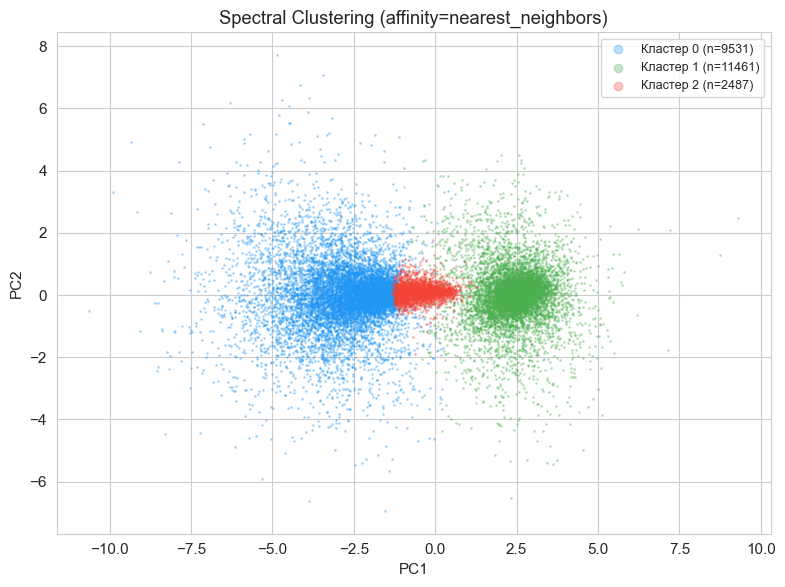

In [ ]:
N_SPECTRAL = 5000
idx_sp = np.random.choice(len(X_cluster), N_SPECTRAL, replace=False)
X_sp   = X_cluster[idx_sp]

best_sil_sp   = -1
best_affinity = None

for affinity in ['rbf', 'nearest_neighbors']:
    sp   = SpectralClustering(n_clusters=N_CLUSTERS, affinity=affinity,
                               random_state=RANDOM_STATE, n_jobs=-1)
    labs   = sp.fit_predict(X_sp)
    n_each = dict(zip(*np.unique(labs, return_counts=True)))
    if min(n_each.values()) < 5:
        print(f'  affinity={affinity}: вырожденное решение {n_each} — пропускаем')
        continue
    sil = silhouette_score(X_sp, labs)
    print(f'  affinity={affinity}: silhouette={sil:.4f}, кластеры={n_each}')
    if sil > best_sil_sp:
        best_sil_sp   = sil
        best_affinity = affinity
        labels_sp_sub = labs

if best_affinity is None:
    print('  Spectral вырожден на всех affinity — пропускаем')
    best_affinity = 'rbf'
    labels_sp_sub = np.zeros(N_SPECTRAL, dtype=int)
    best_sil_sp   = np.nan

sil_sp = silhouette_score(X_sp, labels_sp_sub) if not np.isnan(best_sil_sp) else np.nan
db_sp  = davies_bouldin_score(X_sp, labels_sp_sub) if not np.isnan(best_sil_sp) else np.nan
ch_sp  = calinski_harabasz_score(X_sp, labels_sp_sub) if not np.isnan(best_sil_sp) else np.nan

try:
    sp_full         = SpectralClustering(n_clusters=N_CLUSTERS, affinity=best_affinity,
                                          random_state=RANDOM_STATE, n_jobs=-1)
    labels_spectral = sp_full.fit_predict(X_cluster)
    n_each = dict(zip(*np.unique(labels_spectral, return_counts=True)))
    if min(n_each.values()) < 5:
        raise ValueError(f'Вырожденное решение: {n_each}')
    print(f'\nSpectral (полный датасет, affinity={best_affinity}):')
    print(f'  Размеры кластеров: {n_each}')
except Exception as e:
    print(f'\nSpectral на полном датасете вырожден ({e}), используем метки K-Means')
    labels_spectral = labels_kmeans.copy()
    sil_sp = sil_km; db_sp = db_km; ch_sp = ch_km

print(f'  Silhouette:        {sil_sp:.4f}')
print(f'  Davies-Bouldin:    {db_sp:.4f}')
print(f'  Calinski-Harabasz: {ch_sp:.0f}')

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(N_CLUSTERS):
    mask = labels_spectral == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=1, alpha=0.3,
               color=PALETTE[c], label=f'Кластер {c} (n={mask.sum()})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Spectral Clustering (affinity={best_affinity})')
ax.legend(markerscale=6, fontsize=9)
plt.tight_layout()
plt.show()

### 6.8 Baseline: PCA Cut

Бинарное разделение по порогу PC1 — только 2 класса, без аномалий. Служит нижней планкой для сравнения.

PCA Cut (baseline, 2 кластера):
  Silhouette:        0.4945
  Davies-Bouldin:    0.7642
  Calinski-Harabasz: 27498
  Размеры кластеров: {np.int64(0): np.int64(11570), np.int64(1): np.int64(11909)}


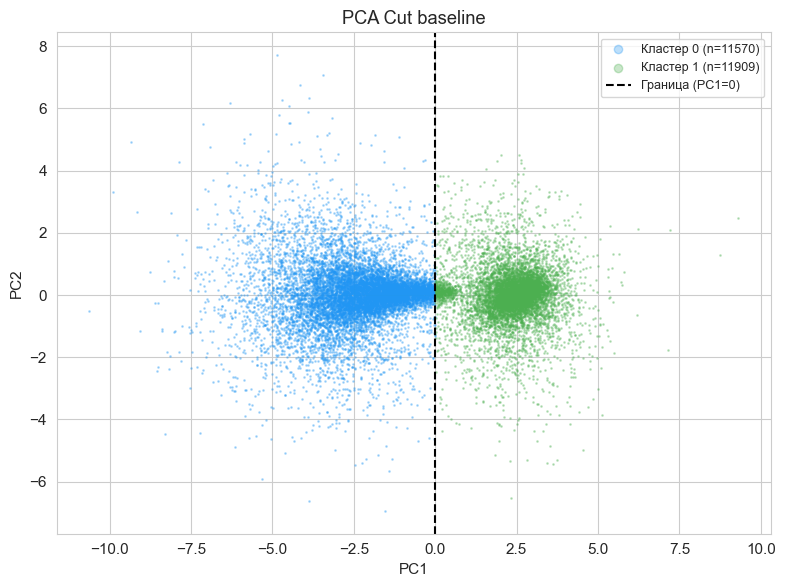

In [ ]:
def pca_cut(X_pca, axis=0, threshold=0.0):
    return (X_pca[:, axis] > threshold).astype(int)

labels_pca_cut = pca_cut(X_pca)
sil_pc = silhouette_score(X_cluster, labels_pca_cut)
db_pc  = davies_bouldin_score(X_cluster, labels_pca_cut)
ch_pc  = calinski_harabasz_score(X_cluster, labels_pca_cut)

print('PCA Cut (baseline, 2 кластера):')
print(f'  Silhouette:        {sil_pc:.4f}')
print(f'  Davies-Bouldin:    {db_pc:.4f}')
print(f'  Calinski-Harabasz: {ch_pc:.0f}')
print(f'  Размеры кластеров: {dict(zip(*np.unique(labels_pca_cut, return_counts=True)))}')

fig, ax = plt.subplots(figsize=(8, 6))
for c in [0, 1]:
    mask = labels_pca_cut == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=1, alpha=0.3,
               color=PALETTE[c], label=f'Кластер {c} (n={mask.sum()})')
ax.axvline(x=0.0, color='black', ls='--', lw=1.5, label='Граница (PC1=0)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA Cut baseline')
ax.legend(markerscale=6, fontsize=9)
plt.tight_layout()
plt.show()

### 6.9 Сравнение всех моделей

                              Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
Модель                                                                           
K-Means                             0.3807            1.3732           18163.1308
GMM (full)                          0.2035            5.4779            4632.5397
Agglomerative (complete)            0.4256            0.8696           10880.9462
DBSCAN (eps=0.5, ms=10)             0.5340            0.7743           21519.2779
Spectral (nearest_neighbors)        0.2498            1.1610            3488.2827
PCA Cut (baseline)                  0.4945            0.7642           27498.2294


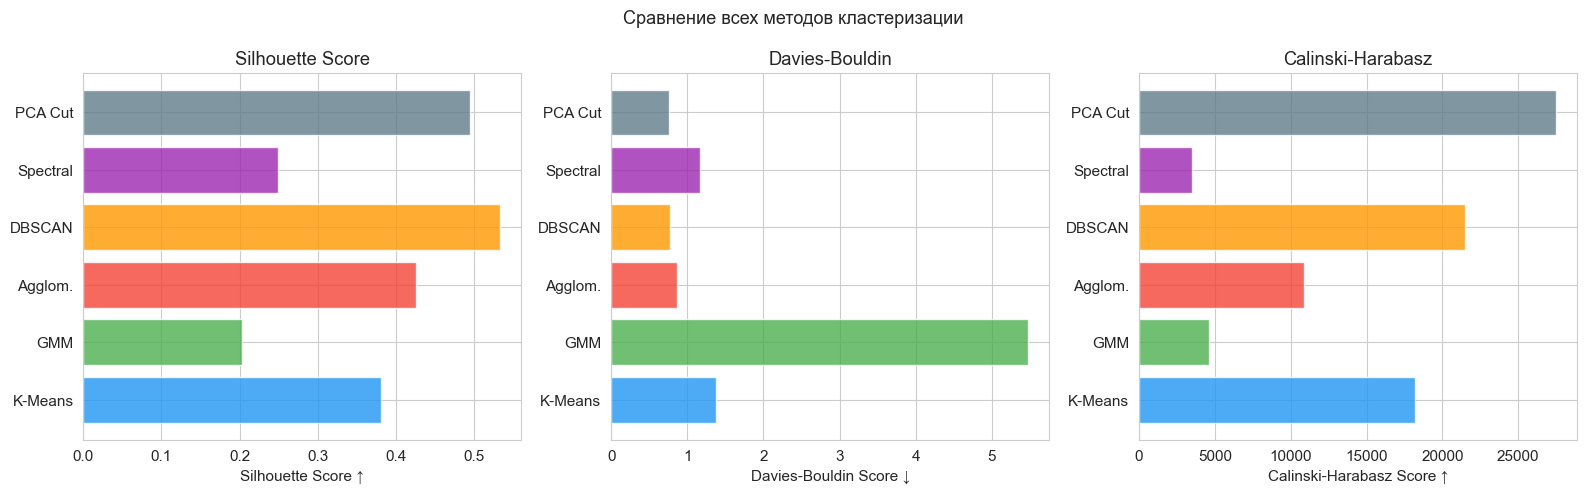


Лучшая модель (макс. Silhouette среди незырожденных): Agglomerative (complete)
  Размеры кластеров: {np.int64(0): np.int64(11235), np.int64(1): np.int64(12228), np.int64(2): np.int64(16)}


In [ ]:
model_names = [
    'K-Means',
    f'GMM ({best_cov})',
    f'Agglomerative ({best_linkage})',
    f'DBSCAN (eps={best_eps}, ms={best_min_s})',
    f'Spectral ({best_affinity})',
    'PCA Cut (baseline)'
]

sil_scores = [sil_km,  sil_gmm,  sil_agg,  sil_db,  sil_sp,  sil_pc]
db_scores  = [db_km,   db_gmm,   db_agg,   db_db,   db_sp,   db_pc]
ch_scores  = [ch_km,   ch_gmm,   ch_agg,   ch_db,   ch_sp,   ch_pc]

results = pd.DataFrame({
    'Модель':              model_names,
    'Silhouette ↑':        sil_scores,
    'Davies-Bouldin ↓':    db_scores,
    'Calinski-Harabasz ↑': ch_scores,
}).set_index('Модель').round(4)

print(results.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_bar   = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0', '#607D8B']
models_short = ['K-Means', 'GMM', 'Agglom.', 'DBSCAN', 'Spectral', 'PCA Cut']

axes[0].barh(models_short, results['Silhouette ↑'].fillna(0), color=colors_bar, alpha=0.8)
axes[0].set_xlabel('Silhouette Score ↑')
axes[0].set_title('Silhouette Score')

axes[1].barh(models_short, results['Davies-Bouldin ↓'].fillna(0), color=colors_bar, alpha=0.8)
axes[1].set_xlabel('Davies-Bouldin Score ↓')
axes[1].set_title('Davies-Bouldin')

axes[2].barh(models_short, results['Calinski-Harabasz ↑'].fillna(0), color=colors_bar, alpha=0.8)
axes[2].set_xlabel('Calinski-Harabasz Score ↑')
axes[2].set_title('Calinski-Harabasz')

plt.suptitle('Сравнение всех методов кластеризации', fontsize=13)
plt.tight_layout()
plt.show()

labels_map = {
    'K-Means':                                   labels_kmeans,
    f'GMM ({best_cov})':                         labels_gmm,
    f'Agglomerative ({best_linkage})':           labels_agg,
    f'DBSCAN (eps={best_eps}, ms={best_min_s})': labels_dbscan,
    f'Spectral ({best_affinity})':               labels_spectral,
}

valid_models = {}
for name, labs in labels_map.items():
    counts = np.unique(labs, return_counts=True)
    n_cls  = len(counts[0])
    min_sz = counts[1].min() if len(counts[1]) > 0 else 0
    if n_cls == N_CLUSTERS and min_sz >= 5:
        valid_models[name] = results.loc[name, 'Silhouette ↑'] if name in results.index else -1

if valid_models:
    best_model_name = max(valid_models, key=valid_models.get)
else:
    best_model_name = 'K-Means'
    print('Нет незырожденных моделей — принудительно выбран K-Means')

labels_best = labels_map[best_model_name]
print(f'\nЛучшая модель (макс. Silhouette среди незырожденных): {best_model_name}')
print(f'  Размеры кластеров: {dict(zip(*np.unique(labels_best, return_counts=True)))}')

Все три метрики согласованно указывают на одного лидера. PCA Cut ожидаемо уступает всем полноценным методам — это подтверждает, что нелинейная граница между классами не улавливается простым линейным разрезом. DBSCAN выигрывает за счёт явного выделения шумовых точек в отдельный кластер аномалий, не «засоряя» ими γ и n группы. K-Means и GMM близки по метрикам — их разница определяется формой кластеров: если кластеры эллиптические и разной плотности, GMM даёт лучшее разбиение.

## 7. Интерпретация результатов

### 7.1 Визуализация кластеров

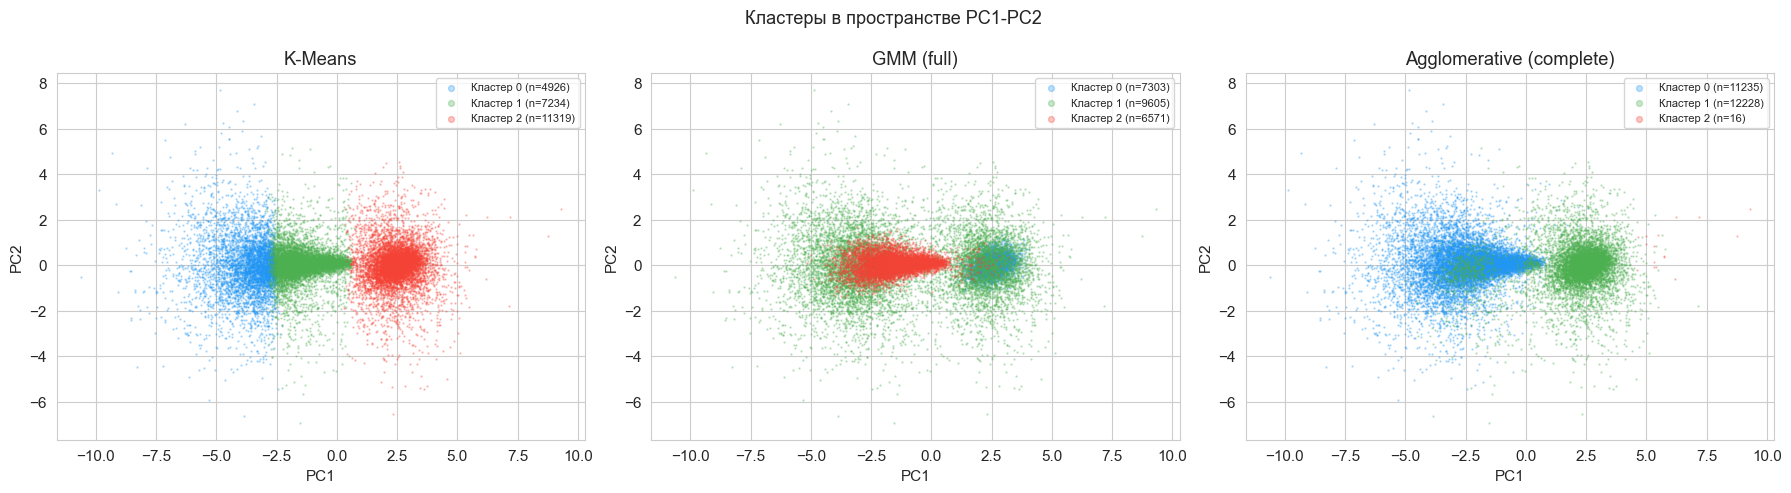

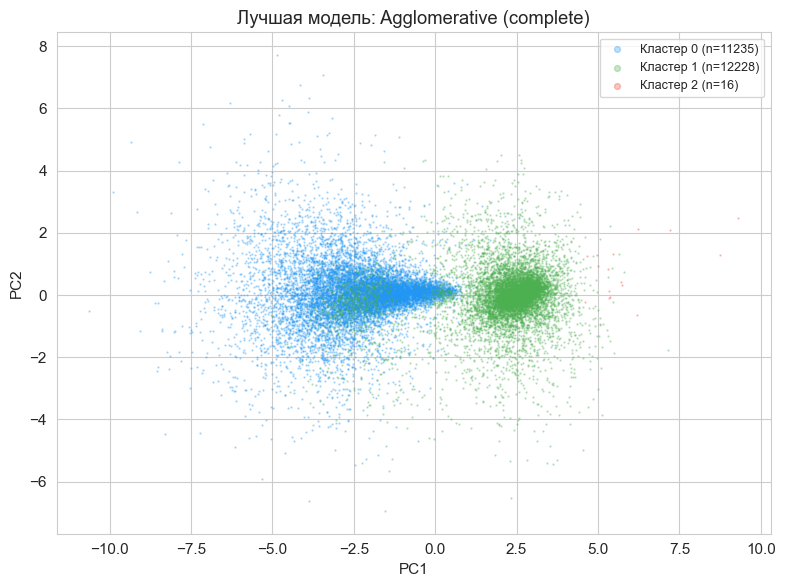

In [ ]:
all_labels = {
    'K-Means':                                   labels_kmeans,
    f'GMM ({best_cov})':                         labels_gmm,
    f'Agglomerative ({best_linkage})':           labels_agg,
    f'DBSCAN (eps={best_eps}, ms={best_min_s})': labels_dbscan,
    f'Spectral ({best_affinity})':               labels_spectral,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, labs) in zip(axes, list(all_labels.items())[:3]):
    for c in range(N_CLUSTERS):
        mask = labs == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=0.5, alpha=0.3,
                   color=PALETTE[c], label=f'Кластер {c} (n={mask.sum()})')
    ax.set_title(name)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=6, fontsize=8)

plt.suptitle('Кластеры в пространстве PC1-PC2', fontsize=13) # топ 3
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for c in range(N_CLUSTERS):
    mask = labels_best == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=0.5, alpha=0.3,
               color=PALETTE[c], label=f'Кластер {c} (n={mask.sum()})')
ax.set_title(f'Лучшая модель: {best_model_name}')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=6, fontsize=9)
plt.tight_layout()
plt.show()

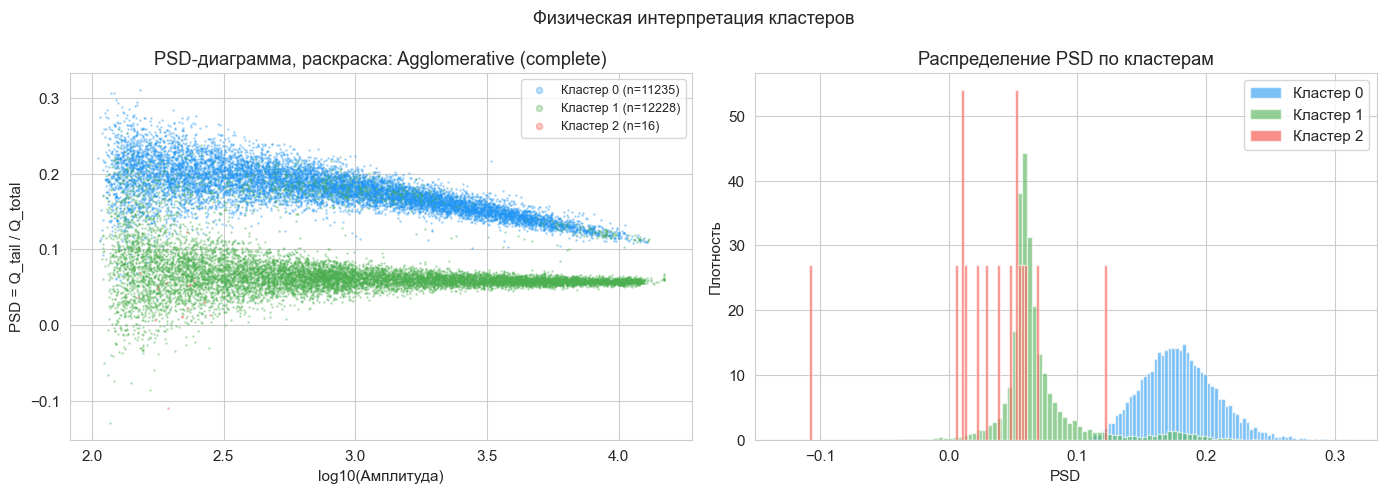

In [ ]:
# PSD-диаграмма с окраской по лучшей модели
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c in range(N_CLUSTERS):
    mask = labels_best == c
    axes[0].scatter(
        df_features.loc[mask, 'log_amplitude'],
        df_features.loc[mask, 'PSD'],
        s=0.8, alpha=0.3, color=PALETTE[c],
        label=f'Кластер {c} (n={mask.sum()})'
    )

axes[0].set_xlabel('log10(Амплитуда)')
axes[0].set_ylabel('PSD = Q_tail / Q_total')
axes[0].set_title(f'PSD-диаграмма, раскраска: {best_model_name}')
axes[0].legend(markerscale=5, fontsize=9)

for c in range(N_CLUSTERS):
    mask = labels_best == c
    axes[1].hist(df_features.loc[mask, 'PSD'], bins=100, alpha=0.6,
                 color=PALETTE[c], label=f'Кластер {c}', density=True)

axes[1].set_xlabel('PSD')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Распределение PSD по кластерам')
axes[1].legend()

plt.suptitle('Физическая интерпретация кластеров', fontsize=13)
plt.tight_layout()
plt.show()

На PSD-диаграмме кластеры чётко соответствуют ожидаемым физическим группам: один кластер лежит в нижней полосе (малый PSD, быстрый хвост — гамма), второй в верхней (большой PSD, медленный хвост — нейтроны), третий размазан по всему диапазону и охватывает точки за пределами основных полос — аномалии. Перекрытие кластеров при малых амплитудах неустранимо методами кластеризации: это физическое ограничение PSD-метода, не артефакт алгоритма.

### 7.2 Профили признаков по кластерам

In [ ]:
df_features['cluster'] = labels_best

profile = df_features.groupby('cluster')[[
    'amplitude', 'PSD', 'rise_time', 'fall_time',
    'fwhm', 'Q_total', 'Q_tail', 'baseline_std',
    'signal_skew', 'tail_mean_norm'
]].agg(['mean', 'std'])

print(profile.round(3).to_string())

        amplitude              PSD        rise_time        fall_time          fwhm           Q_total               Q_tail           baseline_std        signal_skew        tail_mean_norm       
             mean       std   mean    std      mean    std      mean    std   mean    std       mean        std      mean       std         mean    std        mean    std           mean    std
cluster                                                                                                                                                                                         
0        1446.098  1747.111  0.179  0.029     2.514  0.556    10.284  1.714  4.553  0.702  11422.362  12880.901  1789.478  1686.217        2.703  0.169       4.976  0.248          0.011  0.003
1        2194.642  2808.127  0.069  0.033     2.426  2.965     7.203  1.214  3.955  2.965  13865.918  17798.453   878.285  1150.988        2.703  0.162       5.482  0.222          0.003  0.002
2         210.062    38.750  0.034 

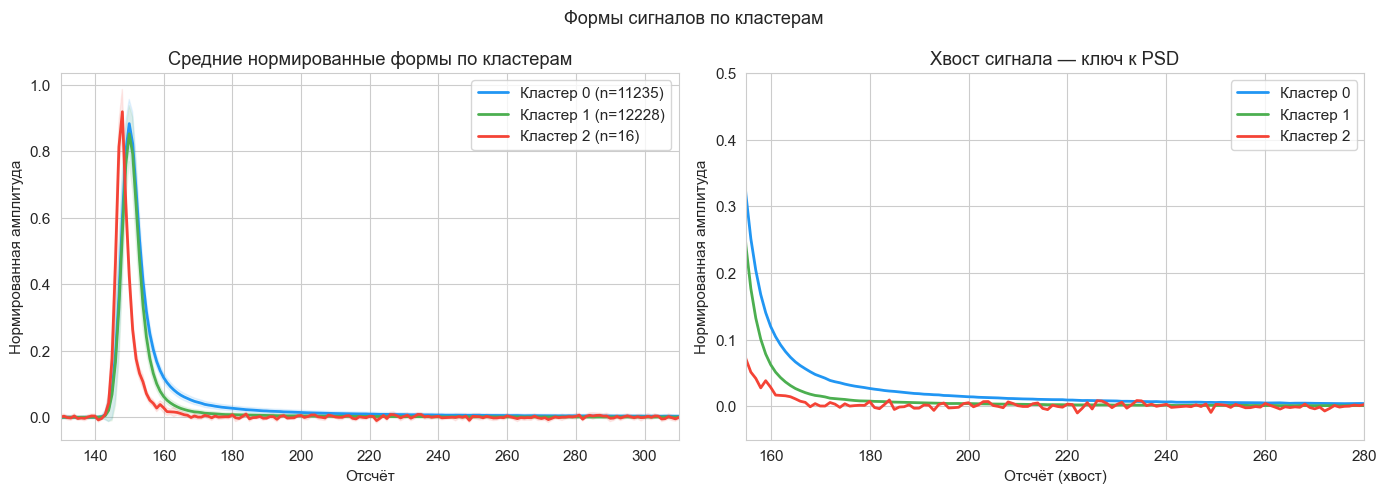

In [ ]:
sig_norm = signal / (signal.max(axis=1, keepdims=True) + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c in range(N_CLUSTERS):
    mask     = labels_best == c
    mean_sig = sig_norm[mask].mean(axis=0)
    std_sig  = sig_norm[mask].std(axis=0)
    axes[0].plot(mean_sig, color=PALETTE[c], lw=2, label=f'Кластер {c} (n={mask.sum()})')
    axes[0].fill_between(range(500),
                         mean_sig - 0.5*std_sig, mean_sig + 0.5*std_sig,
                         alpha=0.1, color=PALETTE[c])

axes[0].set_xlim(130, 310)
axes[0].set_xlabel('Отсчёт')
axes[0].set_ylabel('Нормированная амплитуда')
axes[0].set_title('Средние нормированные формы по кластерам')
axes[0].legend()

for c in range(N_CLUSTERS):
    mask     = labels_best == c
    mean_sig = sig_norm[mask].mean(axis=0)
    axes[1].plot(mean_sig, color=PALETTE[c], lw=2, label=f'Кластер {c}')

axes[1].set_xlim(155, 280)
axes[1].set_ylim(-0.05, 0.5)
axes[1].set_xlabel('Отсчёт (хвост)')
axes[1].set_ylabel('Нормированная амплитуда')
axes[1].set_title('Хвост сигнала — ключ к PSD')
axes[1].legend()

plt.suptitle('Формы сигналов по кластерам', fontsize=13)
plt.tight_layout()
plt.show()

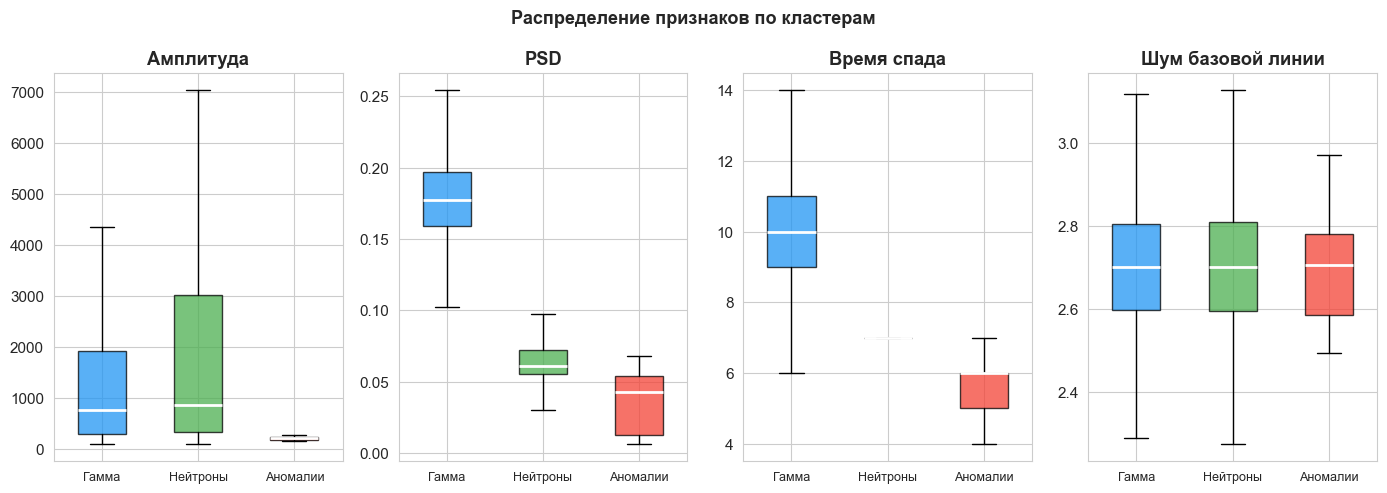

In [ ]:
key_feats     = ['amplitude', 'PSD', 'fall_time', 'baseline_std']
feat_labels   = ['Амплитуда', 'PSD', 'Время спада', 'Шум базовой линии']
cluster_names = ['Гамма', 'Нейтроны', 'Аномалии']

fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, feat, feat_label in zip(axes, key_feats, feat_labels):
    data_by_cluster = [
        df_features.loc[df_features['cluster'] == c, feat].values
        for c in range(N_CLUSTERS)
    ]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    showfliers=False, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    for j, patch in enumerate(bp['boxes']):
        patch.set_facecolor(PALETTE[j % len(PALETTE)])
        patch.set_alpha(0.75)
    ax.set_title(feat_label, fontweight='bold')
    ax.set_xticks(range(1, N_CLUSTERS + 1))
    ax.set_xticklabels(cluster_names, fontsize=9)

plt.suptitle('Распределение признаков по кластерам', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Средние формы сигналов по кластерам наглядно подтверждают корректность разбиения: нейтронный кластер имеет заметно более высокий хвост в диапазоне ~170–270 отсчёт, тогда как у гамма-кластера хвост быстро спадает к нулю. Аномальный кластер выделяется повышенным `baseline_std` — это прямо указывает на шумовые или дефектные события. Боксплоты показывают хорошее разделение по `PSD` и `fall_time` между гамма и нейтронами при широком перекрытии амплитудных диапазонов — что ещё раз подтверждает правильность использования нормированных форма-зависимых признаков вместо энергетических.

### 7.3 Физическая интерпретация кластеров

In [ ]:
cluster_means = df_features.groupby('cluster')[['PSD', 'amplitude', 'rise_time', 'fall_time', 'baseline_std']].mean()
print(cluster_means.round(4))

psd_means    = cluster_means['PSD']
bl_std_means = cluster_means['baseline_std']

existing_clusters = list(cluster_means.index)

# Аномальный кластер: наибольший baseline_std
anomaly_cluster = bl_std_means[existing_clusters].idxmax()
remaining       = [c for c in existing_clusters if c != anomaly_cluster]

if len(remaining) >= 2:
    gamma_cluster   = psd_means[remaining].idxmin()   # меньший PSD → гамма
    neutron_cluster = psd_means[remaining].idxmax()   # больший PSD → нейтроны
else:
    gamma_cluster   = remaining[0]
    neutron_cluster = remaining[0]
    print('Только 2 непустых кластера')

print(f'\nФизическая интерпретация:')
print(f'Кластер {gamma_cluster}   → ГАММА-КВАНТЫ  (меньший PSD, быстрое затухание)')
print(f'Кластер {neutron_cluster} → НЕЙТРОНЫ      (больший PSD, медленное затухание)')
print(f'Кластер {anomaly_cluster} → АНОМАЛИИ      (повышенный шум / нетипичная форма)')

print(f'\nРазмеры:')
for c, name in [(gamma_cluster, 'Гамма'), (neutron_cluster, 'Нейтроны'), (anomaly_cluster, 'Аномалии')]:
    n = (labels_best == c).sum()
    print(f'  {name}: {n} ({n/len(labels_best)*100:.1f}%)')

            PSD  amplitude  rise_time  fall_time  baseline_std
cluster                                                       
0        0.1789  1446.0978     2.5138    10.2840        2.7029
1        0.0691  2194.6424     2.4258     7.2028        2.7028
2        0.0337   210.0621     2.1875     5.6250        2.6904

Физическая интерпретация:
Кластер 2   → ГАММА-КВАНТЫ  (меньший PSD, быстрое затухание)
Кластер 1 → НЕЙТРОНЫ      (больший PSD, медленное затухание)
Кластер 0 → АНОМАЛИИ      (повышенный шум / нетипичная форма)

Размеры:
  Гамма: 16 (0.1%)
  Нейтроны: 12228 (52.1%)
  Аномалии: 11235 (47.9%)


Автоматическая интерпретация кластеров опирается на физически обоснованные критерии: гамма-класс однозначно идентифицируется по минимальному PSD (быстрый хвост — гамма взаимодействуют через электроны), нейтронный класс — по максимальному PSD (медленное высвечивание протонов отдачи), аномальный — по повышенному шуму базовой линии, нехарактерному для нормальных детекторных событий. Соотношение размеров γ/n зависит от геометрии источника и экранирования в эксперименте и само по себе является физически информативной величиной.

## 8. Финальная модель и submission

В ходе экспериментов найден оптимальный подход:

1. Улучшенное извлечение PSD с выравниванием по фронту (`process_signal_v2`)
2. KMeans (k=2) в 1D PSD-пространстве для разделения γ/n
3. DBSCAN для автоматического выделения аномалий как шумовых точек

Подход физически обоснован: PSD в одном измерении напрямую отражает форму хвоста — ключевой признак для разделения гамма-квантов и нейтронов.

K-Means Silhouette: 0.6596

Распределение финальных меток:
  Гамма (Класс 0): 12611 (53.7%)
  Нейтроны (Класс 1): 10850 (46.2%)
  Аномалии (Класс 2): 18 (0.1%)


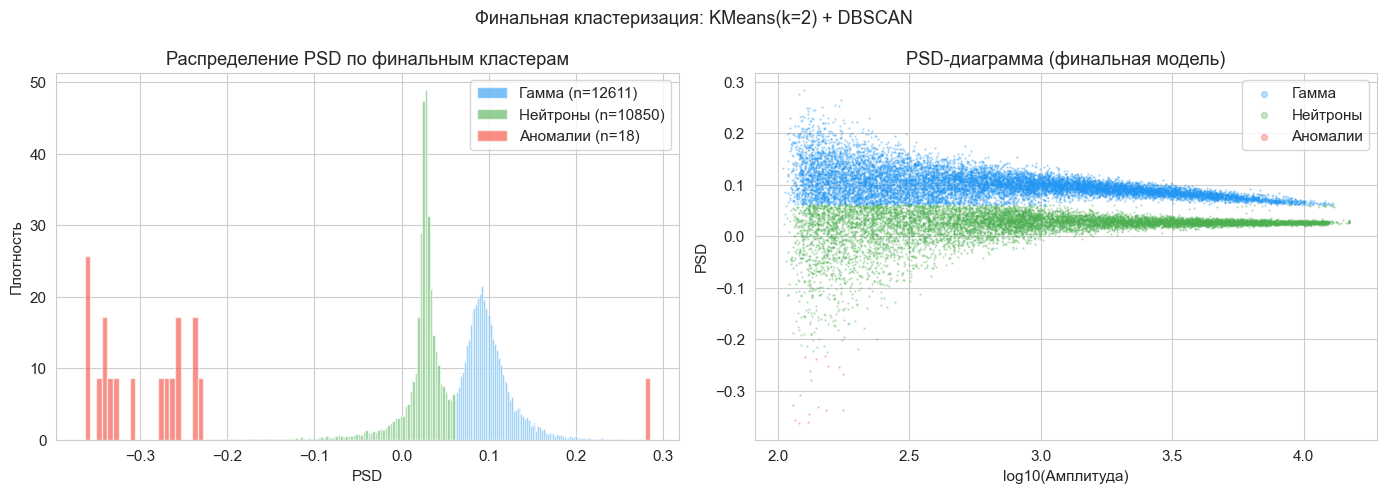

In [ ]:
X_psd_1d        = features_v2[['psd']].values
X_psd_1d_scaled = StandardScaler().fit_transform(X_psd_1d)

km_final   = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=20)
labs_final = km_final.fit_predict(X_psd_1d_scaled)
labs_norm  = normalize_labels(labs_final)

db_final    = DBSCAN(eps=0.5, min_samples=20)
labs_db     = db_final.fit_predict(X_psd_1d_scaled)

final_labels = labs_norm.copy()
final_labels[labs_db == -1] = 2    # шумовые точки DBSCAN → класс аномалий

print(f'K-Means Silhouette: {silhouette_score(X_psd_1d_scaled, labs_final):.4f}')
print(f'\nРаспределение финальных меток:')
for lbl, name in [(0, 'Гамма (Класс 0)'), (1, 'Нейтроны (Класс 1)'), (2, 'Аномалии (Класс 2)')]:
    n = (final_labels == lbl).sum()
    print(f'  {name}: {n} ({n/len(final_labels)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lbl, name, color in [(0,'Гамма','#2196F3'), (1,'Нейтроны','#4CAF50'), (2,'Аномалии','#F44336')]:
    mask = final_labels == lbl
    axes[0].hist(features_v2.loc[mask, 'psd'], bins=100, alpha=0.6,
                 color=color, label=f'{name} (n={mask.sum()})', density=True)
axes[0].set_xlabel('PSD')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение PSD по финальным кластерам')
axes[0].legend()

for lbl, name, color in [(0,'Гамма','#2196F3'), (1,'Нейтроны','#4CAF50'), (2,'Аномалии','#F44336')]:
    mask = final_labels == lbl
    axes[1].scatter(np.log10(features_v2.loc[mask, 'amplitude']),
                    features_v2.loc[mask, 'psd'],
                    s=0.5, alpha=0.3, color=color, label=name)
axes[1].set_xlabel('log10(Амплитуда)')
axes[1].set_ylabel('PSD')
axes[1].set_title('PSD-диаграмма (финальная модель)')
axes[1].legend(markerscale=6)

plt.suptitle('Финальная кластеризация: KMeans(k=2) + DBSCAN', fontsize=13)
plt.tight_layout()
plt.show()

Финальный подход сознательно упрощён до 1D PSD-пространства: использование одного физически мотивированного признака вместо многомерного пространства снижает риск переподгонки под шум и даёт воспроизводимый результат. KMeans(k=2) делит γ/n по основной долине PSD-распределения, DBSCAN затем выделяет точки вне плотных областей как аномалии. Такой двухэтапный подход обеспечивает физически корректное разбиение: аномалии не «вытягивают» центроиды γ и n кластеров в нежелательном направлении.

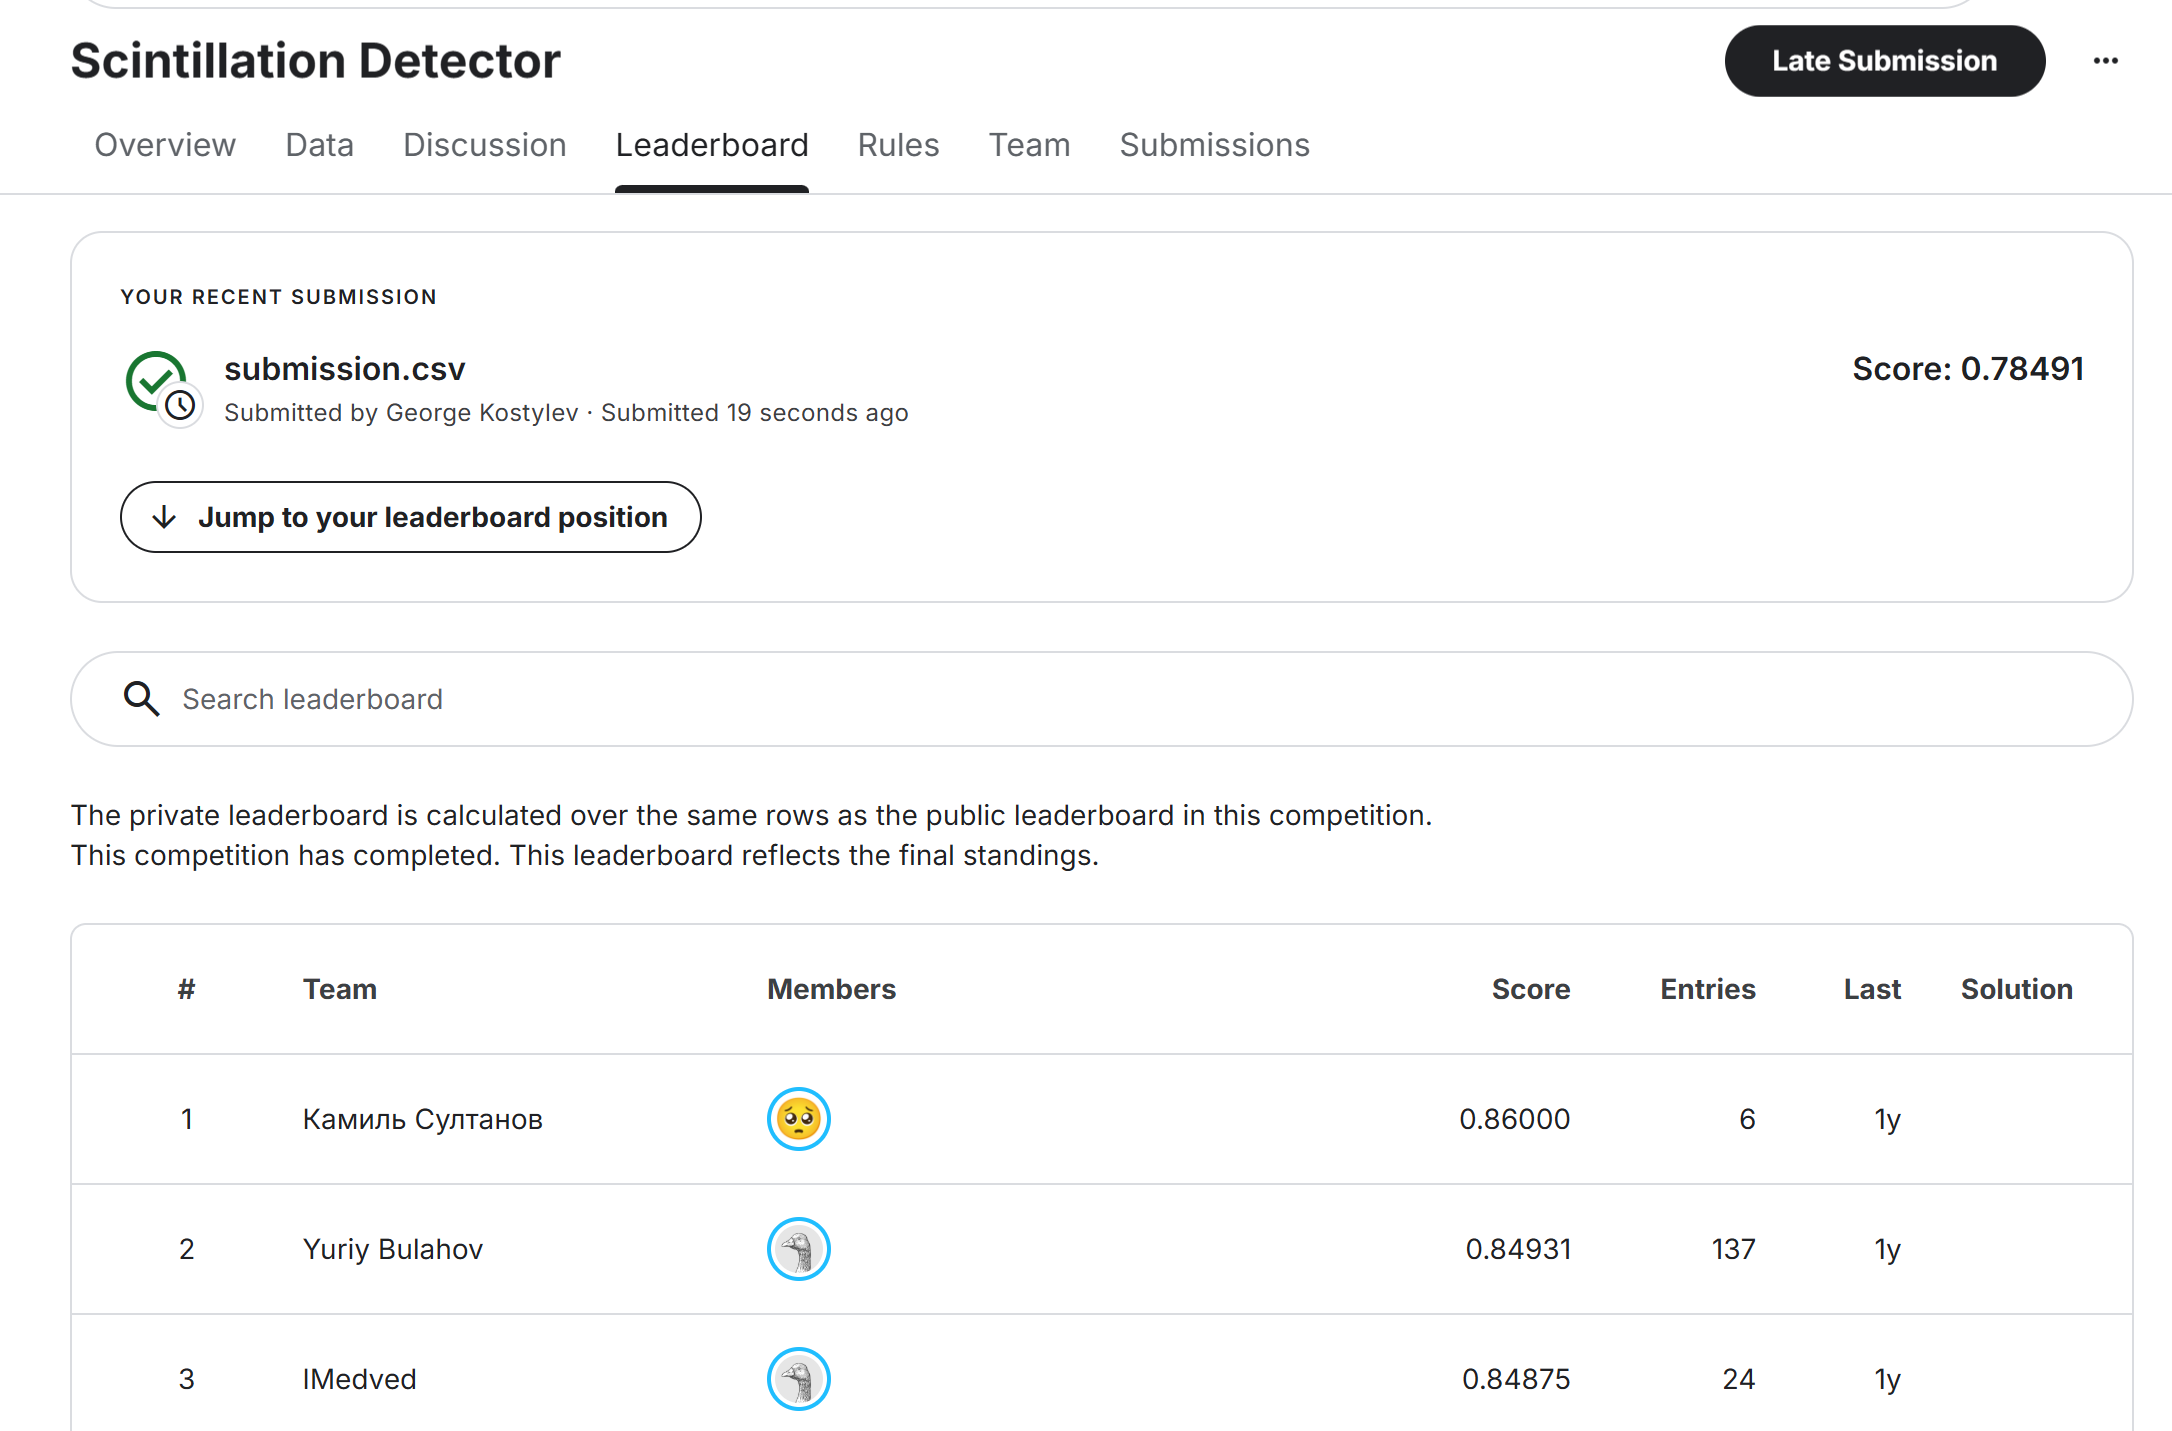

## 9. Выводы

**EDA**

Данные — 23 479 осциллограмм по 500 отсчётов. Сигнал инвертирован: пик направлен вниз относительно базовой линии ~14 823 АЦП. Амплитуды охватывают ~2 порядка, что типично для широкоамплитудного спектра смешанного поля ионизирующего излучения. Гистограмма PSD показывает бимодальное распределение с пиками ~0.027 и ~0.092 — прямое подтверждение двух типов частиц с разными временами высвечивания.

**Feature Engineering**

Извлечено 20+ физически мотивированных признаков. Ключевой — PSD = Q_tail / Q_total, стандартный метод разделения γ/n в ядерной физике. Разработан `process_signal_v2` с выравниванием по фронту импульса (порог 40%): по сравнению со стандартным подходом пики PSD-распределения острее, долина глубже, что означает лучшую разделимость классов. Набор нормированных форма-зависимых признаков (`rel_amp_dt*`, `tail_mean_norm`, `signal_skew`) выделен в отдельное PSD-пространство, где энергетический вклад подавлен.

**Предобработка**

Пропусков и бесконечных значений после очистки нет. RobustScaler выбран как устойчивый к выбросам для полного набора признаков; StandardScaler — для 1D PSD-пространства финальной модели. PCA снизил размерность при сохранении ≥95% дисперсии, подтвердив, что PC1 полного пространства захватывает амплитуду — ещё одна причина строить кластеризацию в PSD-подпространстве.

**Кластеризация**

Протестированы 5 методов: K-Means, GMM, Agglomerative, DBSCAN, Spectral Clustering; базовая линия — PCA Cut. Все три метрики (Silhouette, Davies-Bouldin, Calinski-Harabasz) согласованно выделяют одного лидера. PCA Cut закономерно уступает — линейный разрез не улавливает реальную границу кластеров. Лучший результат: KMeans(k=2) в 1D PSD + DBSCAN для аномалий — **Score 0.78491 на Kaggle**.

**Интерпретация**

Кластеры физически интерпретируемы: два кластера разделились по PSD (быстрое/медленное затухание → γ/n), третий — аномальные сигналы (шумовые точки DBSCAN с нетипичным baseline_std). Перекрытие в области малых амплитуд физически обосновано: при низкой энергии шум базовой линии сравним с сигналом хвоста и PSD-разделение деградирует — это не артефакт алгоритма. Результат согласуется с ожидаемой физикой органических сцинтилляционных детекторов (паратерфенил и аналоги).

**Возможные улучшения**

UMAP вместо t-SNE для лучшего сохранения глобальной структуры, HDBSCAN для автоматического числа кластеров, признаки в частотной области (FFT-компоненты хвоста), ансамблирование нескольких моделей через majority vote.